# 06 - Feature Engineering

Các bài toán được phát biểu đều có thể quy về 1 dạng của bài toán predict price. Vì vậy, ta chỉ cần 1 kiểu feature engineering

# 1. Set Up

In [316]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import math
import pickle
from datetime import datetime

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "data" and PROJECT_ROOT.parent.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "preprocessors"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_PATH = PROCESSED_DIR / "laptop_processed.csv"
PROCESSED_LEVEL_PATH = PROCESSED_DIR / "laptop_processed_level.csv"
PROCESSED_NOLEVEL_PATH = PROCESSED_DIR / "laptop_processed_numeric.csv"

FEATURE_CONFIG_LEVEL_PATH = ARTIFACTS_DIR / "feature_config_level.joblib"
FEATURE_CONFIG_NOLEVEL_PATH = ARTIFACTS_DIR / "feature_config_numeric.joblib"

DATA_PATH = PROJECT_ROOT / "data" / "intern" / "laptop_feature_selection_for_fe.csv"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing merged dataset: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Data shape: {df.shape}")

PROJECT_ROOT: y:\Python\Laptop-Price-Prediction
Data shape: (10080, 35)


# 2. Overview of the dataset

Kiểm tra lại dữ liệu trước khi feature engineering

In [317]:
print(df.columns.tolist())
display(df.dtypes.to_frame("dtype"))

['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_grouped', 'model_grouped', 'cpu_brand', 'cpu_tier', 'gpu_tier', 'storage_type_clean', 'condition_clean', 'warranty_status', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing', 'ram_suspicious', 'storage_suspicious', 'screen_suspicious', 'potential_dedicated_gpu', 'repair_mismatch', 'is_soft_duplicate_spec', 'target_price', 'log_target_price', 'source', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu', 'cpu_family_from_raw', 'cpu_model_code_group', 'gpu_tier_v2']


,dtype
ram_gb,float64
storage_gb,float64
screen_size_inch,float64
brand_grouped,object
model_grouped,object
cpu_brand,object
cpu_tier,object
gpu_tier,object
storage_type_clean,object
condition_clean,object


In [318]:
# Chuyển đổi type cho chính xác
bool_cols = [
    'no_info_brand', # int64
    'no_info_model', # int64
    'no_info_cpu_brand', # int64
    'no_info_cpu_tier', # int64
    'no_info_gpu', # int64
    'model_is_rare' # object
]

for col in bool_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.lower()
                .map({
                    'true': True,
                    'false': False,
                    '1': True,
                    '0': False
                })
                .fillna(False)
                .astype(bool)
            )
        else:
            df[col] = df[col].fillna(0).astype(int).astype(bool)

In [319]:
# 1. Pop cột source ra khỏi df
source = df.pop("source")

# 2. Tách target
target = df[["target_price", "log_target_price"]].copy()

y_price = df["target_price"].copy()
y_log_price = df["log_target_price"].copy()

# 3. Tạo X bằng cách bỏ target khỏi df
X = df.drop(columns=["target_price", "log_target_price"])

# 4. Chia nhóm feature theo kiểu dữ liệu
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

boolean_features = X.select_dtypes(include=["bool"]).columns.tolist()

# 5. In kết quả kiểm tra
print("Source shape:", source.shape)

print("Target columns:", target.columns.tolist())
print("y_price:", y_price.name)
print("y_log_price:", y_log_price.name)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Boolean features:", boolean_features)

print("Số numeric:", len(numeric_features))
print("Số categorical:", len(categorical_features))
print("Số boolean:", len(boolean_features))

Source shape: (10080,)
Target columns: ['target_price', 'log_target_price']
y_price: target_price
y_log_price: log_target_price
Numeric features: ['ram_gb', 'storage_gb', 'screen_size_inch']
Categorical features: ['brand_grouped', 'model_grouped', 'cpu_brand', 'cpu_tier', 'gpu_tier', 'storage_type_clean', 'condition_clean', 'warranty_status', 'cpu_family_from_raw', 'cpu_model_code_group', 'gpu_tier_v2']
Boolean features: ['brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing', 'ram_suspicious', 'storage_suspicious', 'screen_suspicious', 'potential_dedicated_gpu', 'repair_mismatch', 'is_soft_duplicate_spec', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu']
Số numeric: 3
Số categorical: 11
Số boolean: 18


# Type of features
Chúng ta sẽ giữ cả 2 target trong data để kiểm tra cả 2, vì theo EDA trước đó cho thấy giá gốc cũng quan trọng dù cho distribution không có phân phối chuẩn

Các cột numeric bao gồm `ram_gb`, `storage_gb`, `screen_size_inch`, đây là các tính hiệu quan trọng. Đồng thời trong dataset hiện tại cũng sẽ khảo sát các giá trị được categorical hóa của các feature này để kiểm tra xem cách nào mang lại hiệu quả tốt hơn.

Các feature mang tính categorical có thể được feature hóa theo hướng One-hot hoặc Ordinary tùy theo tính hiệu của chúng

Các feature `boolean` chủ yếu gồm các tính hiệu missing hay no-infomation và các tính hiệu cảnh báo nói chung.

In [320]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

# Chỉ hiện các cột có missing_count > 0
missing_summary = missing_summary[missing_summary["missing_count"] > 0]

display(missing_summary)

Shape: (10080, 34)
Duplicate rows: 209


,missing_count,missing_percent
screen_size_inch,988,9.802
storage_gb,577,5.724
ram_gb,181,1.796


Các feature này sẽ được fill bằng Orther trogn quá tình feature engineering

In [321]:
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

bool_summary = pd.DataFrame({
    "true_count": df[bool_cols].sum(),
    "true_percent": df[bool_cols].mean() * 100
}).sort_values("true_percent", ascending=False)

display(bool_summary)

,true_count,true_percent
no_info_model,7355,72.966
is_soft_duplicate_spec,2514,24.940
no_info_gpu,2384,23.651
model_is_rare,2147,21.300
gpu_missing,1514,15.020
screen_missing,1027,10.188
no_info_cpu_tier,771,7.649
storage_missing,613,6.081
no_info_brand,391,3.879
no_info_cpu_brand,344,3.413


Ta loại `is_soft_duplicate_spec` và xóa đi các dòng duplicate, đồng thời các cột constant sẽ đucợ xóa đi. Các feature có true percent nhhor hơn 1% được giữ lại và có thể bị xóa đi trong qua trình evaluation

In [322]:
# Xóa các dòng soft duplicate trước
df = df[df["is_soft_duplicate_spec"] == False].copy()

# Sau đó bỏ luôn cột đánh dấu duplicate
df = df.drop(columns=["is_soft_duplicate_spec"])

# Xóa các cột constant
df = df.drop(columns=["storage_suspicious"])
df = df.drop(columns=["screen_suspicious"])

In [323]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

cardinality = pd.DataFrame({
    "n_unique": df[cat_cols].nunique(),
    "top_value": df[cat_cols].mode().iloc[0],
    "top_freq": [df[col].value_counts(dropna=False).iloc[0] for col in cat_cols]
}).sort_values("n_unique", ascending=False)

display(cardinality)

,n_unique,top_value,top_freq
cpu_model_code_group,100,Other,5738
cpu_family_from_raw,33,Other,3110
model_grouped,32,Other,4841
brand_grouped,13,Dell,2117
gpu_tier,11,Integrated - Intel,2528
cpu_tier,9,Mid,2789
gpu_tier_v2,9,Other,5788
cpu_brand,6,Intel,5930
storage_type_clean,4,SSD,6513
warranty_status,4,Manufacturer,2871


# 3. Check Feture Engineering - Boolean Feature

Chúng ta sẽ khảo sát các boolean feature về một số khía cạnh để kiểm tra độ ảnh hưởng của chúng đến target và đối với các feature khác.

Kiểm tra các feature boolean hiện tại

In [324]:
boolean_features = df.select_dtypes(include=["bool"]).columns.tolist()
print("Boolean features:", boolean_features)
print("Số boolean:", len(boolean_features))

Boolean features: ['brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing', 'ram_suspicious', 'potential_dedicated_gpu', 'repair_mismatch', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu']
Số boolean: 15


In [325]:
# Các cặp feature và cột no_info tương ứng
check_pairs = {
    "brand_grouped": "no_info_brand",
    "model_grouped": "no_info_model",
    "cpu_brand": "no_info_cpu_brand",
    "cpu_tier": "no_info_cpu_tier",
    "gpu_tier": "no_info_gpu",
}

# Các giá trị được xem là không có thông tin
no_info_values = ["other", "unknown", "missing", "orther"]

for feature_col, no_info_col in check_pairs.items():
    print(f"\n===== Kiểm tra {feature_col} -> {no_info_col} =====")

    # Chuẩn hóa text: bỏ khoảng trắng và chuyển về chữ thường
    feature_clean = df[feature_col].astype("string").str.strip().str.lower()

    # Điều kiện feature thuộc nhóm no_info
    condition_other = feature_clean.isin(no_info_values)

    # Điều kiện no_info phải bằng 1
    condition_no_info_true = df[no_info_col].eq(1)

    # Kiểm tra các dòng feature là Other/Unknown/Missing nhưng no_info không bằng 1
    wrong_rows = df[condition_other & ~condition_no_info_true]

    if wrong_rows.empty:
        print("Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1")
    else:
        print("Sai: có dòng Other/Unknown/Missing nhưng no_info != 1")
        print("Số dòng sai:", len(wrong_rows))
        display(wrong_rows[[feature_col, no_info_col]].head(20))


===== Kiểm tra brand_grouped -> no_info_brand =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra model_grouped -> no_info_model =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra cpu_brand -> no_info_cpu_brand =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra cpu_tier -> no_info_cpu_tier =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra gpu_tier -> no_info_gpu =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1


Các missing thuộc về categorical bị thay thế bởi nhóm `no_info_*`, ta xóa đi các cột đó

In [326]:
# Xóa các cột constant
df = df.drop(columns=["gpu_missing"])
df = df.drop(columns=["cpu_missing"])

In [327]:
missing_map = {
    "ram_gb": "ram_missing",
    "screen_size_inch": "screen_missing",
    "storage_gb": "storage_missing"
}

for value_col, missing_col in missing_map.items():
    df[missing_col] = df[value_col].isna()
    df[value_col] = df[value_col].fillna(0)

    print(f"{missing_col}:")
    print(df[missing_col].value_counts())
    print(f"{value_col} NaN:", df[value_col].isna().sum())
    print("-" * 40)

ram_missing:
ram_missing
False    7385
True      181
Name: count, dtype: int64
ram_gb NaN: 0
----------------------------------------
screen_missing:
screen_missing
False    6616
True      950
Name: count, dtype: int64
screen_size_inch NaN: 0
----------------------------------------
storage_missing:
storage_missing
False    7084
True      482
Name: count, dtype: int64
storage_gb NaN: 0
----------------------------------------


Ta còn lại các feature sau `brand_is_rare`, `model_is_rare`, `ram_suspicious`, `potential_dedicated_gpu`, `repair_mismatch`

In [328]:
rare_brands = (
    df.loc[df["brand_is_rare"] == True, "brand_grouped"]
      .value_counts(dropna=False)
)

print(rare_brands)

rare_models = (
    df.loc[df["model_is_rare"] == True, "model_grouped"]
      .value_counts(dropna=False)
)

print(rare_models)

brand_grouped
Other    130
Name: count, dtype: int64
model_grouped
Other    2147
Name: count, dtype: int64


Kết quả hiện tại chưa tốt, bắt đầu config lại với threshold 1%

In [329]:
# Rare category flags: 1 = rare, 0 = not rare
brand_threshold = 0.01
model_threshold = 0.01

brand_freq = df["brand_grouped"].value_counts(normalize=True, dropna=False)
model_freq = df["model_grouped"].value_counts(normalize=True, dropna=False)

df["brand_is_rare"] = (
    df["brand_grouped"].map(brand_freq) < brand_threshold
).astype(int)

df["model_is_rare"] = (
    df["model_grouped"].map(model_freq) < model_threshold
).astype(int)

In [330]:
rare_brands = (
    df.loc[df["brand_is_rare"].eq(1), "brand_grouped"]
      .value_counts(dropna=False)
      .to_frame("count")
)

rare_brands["percent"] = rare_brands["count"] / len(df) * 100
rare_brands["percent"] = rare_brands["percent"].round(3)

rare_models = (
    df.loc[df["model_is_rare"].eq(1), "model_grouped"]
      .value_counts(dropna=False)
      .to_frame("count")
)

rare_models["percent"] = rare_models["count"] / len(df) * 100
rare_models["percent"] = rare_models["percent"].round(3)

print("Rare brands:")
print(rare_brands)

print("\nRare models:")
print(rare_models)

Rare brands:
               count  percent
brand_grouped                
Sony              30    0.397
Toshiba           26    0.344
LG                25    0.330
Gigabyte          14    0.185

Rare models:
                    count  percent
model_grouped                     
Vostro                 75    0.991
ThinkPad X1 Carbon     65    0.859
Legion 5               59    0.780
Latitude 14 7000       58    0.767
Macbook air m4         51    0.674
Latitude E Series      49    0.648
TUF Gaming F15         42    0.555
XPS 13                 42    0.555
TUF Gaming             42    0.555
MacBook Air M2         41    0.542
Pavilion 15            40    0.529
Vivobook 15            40    0.529
Gaming Thin GF         40    0.529
Elitebook 800          37    0.489
X Series               36    0.476
IdeaPad                33    0.436
MacBook Pro M2         30    0.397
Aspire                 30    0.397
ROG Strix              29    0.383
Legion                 26    0.344


In [331]:
ram_sus = df.loc[df["ram_suspicious"] == True, ["ram_gb", "brand_grouped", "model_grouped"]]

print(ram_sus.head(30))
print("Số dòng ram_suspicious:", len(ram_sus))

      ram_gb brand_grouped   model_grouped
84     0.000         Apple           Other
190    0.000         Apple           Other
667    0.000         Apple     MacBook Air
760    0.000            HP         ProBook
1300   0.000         Apple           Other
2252   0.000          Dell       Precision
2375   0.000          ASUS           Other
2449   0.000           MSI           Other
2559   0.000          Sony           Other
2779   0.000         Apple           Other
2840   0.000         Apple     MacBook Pro
3091   0.000         Apple           Other
3136   0.000            HP           Other
3175   0.000        Lenovo        Legion 5
3505   0.000          Dell           Other
3960   0.000         Apple           Other
4148   0.000         Apple  MacBook Pro M2
4348   0.000            HP           Other
4772   0.000          Dell        Inspiron
5406   0.000          ASUS           Other
5608   0.000        Lenovo           Other
Số dòng ram_suspicious: 21


Feature này overlap nhiều với missing, và không cho tháy nhiều thông tin khai thác. Ta drop

In [332]:
df = df.drop(columns=["ram_suspicious"])

In [333]:
print(
    df.loc[df["potential_dedicated_gpu"] == True, "gpu_tier"]
      .value_counts(dropna=False)
)

gpu_tier
Other    40
Name: count, dtype: int64


Ta drop feature này, sẽ do `gpu_tier` phân hóa sau

In [334]:
df = df.drop(columns=["potential_dedicated_gpu"])

In [335]:
print(
    df.loc[df["repair_mismatch"] == True, "condition_clean"]
      .value_counts(dropna=False)
)
print(df["repair_mismatch"].value_counts(dropna=False))
print((df["repair_mismatch"].value_counts(normalize=True, dropna=False) * 100).round(3))

condition_clean
Đã sử dụng (chưa sửa chữa)    16
Name: count, dtype: int64
repair_mismatch
False    7550
True       16
Name: count, dtype: int64
repair_mismatch
False   99.789
True     0.211
Name: proportion, dtype: float64


Không có nhiều ý nghĩa và gần như constant, ta xóa cột này

In [336]:
df = df.drop(columns=["repair_mismatch"])

In [337]:
# ============================================================
# Convert boolean missing/no-info flags to int 0/1
# ============================================================

boolean_flag_cols = [
    "ram_missing",
    "storage_missing",
    "screen_missing",
    "no_info_brand",
    "no_info_model",
    "no_info_cpu_brand",
    "no_info_cpu_tier",
    "no_info_gpu",
]

# Chỉ lấy các cột đang tồn tại trong df
existing_boolean_flag_cols = [
    col for col in boolean_flag_cols
    if col in df.columns
]

df[existing_boolean_flag_cols] = (
    df[existing_boolean_flag_cols]
    .fillna(False)
    .astype(int)
)

print("Converted boolean flags to int:")
print(df[existing_boolean_flag_cols].dtypes)

print("\nValue counts:")
for col in existing_boolean_flag_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).sort_index())

Converted boolean flags to int:
ram_missing          int32
storage_missing      int32
screen_missing       int32
no_info_brand        int32
no_info_model        int32
no_info_cpu_brand    int32
no_info_cpu_tier     int32
no_info_gpu          int32
dtype: object

Value counts:

ram_missing
ram_missing
0    7385
1     181
Name: count, dtype: int64

storage_missing
storage_missing
0    7084
1     482
Name: count, dtype: int64

screen_missing
screen_missing
0    6616
1     950
Name: count, dtype: int64

no_info_brand
no_info_brand
0    7260
1     306
Name: count, dtype: int64

no_info_model
no_info_model
0    2725
1    4841
Name: count, dtype: int64

no_info_cpu_brand
no_info_cpu_brand
0    7278
1     288
Name: count, dtype: int64

no_info_cpu_tier
no_info_cpu_tier
0    6987
1     579
Name: count, dtype: int64

no_info_gpu
no_info_gpu
0    5653
1    1913
Name: count, dtype: int64


# 4. Feature Engineering - Numeric Features

Ta feature engineering theo hướng categorical hóa hoặc scale lại các numeric feature. Tuy nhiên, trước khi quyết định hướng nào tốt hơn, ta sẽ khảo sát phân phối của các numeric feature này để xem chúng có phù hợp với việc giữ nguyên numeric hay không. Nếu phân phối quá lệch hoặc có nhiều giá trị tập trung ở một số mốc nhất định, việc categorical hóa có thể giúp mô hình học tốt hơn.

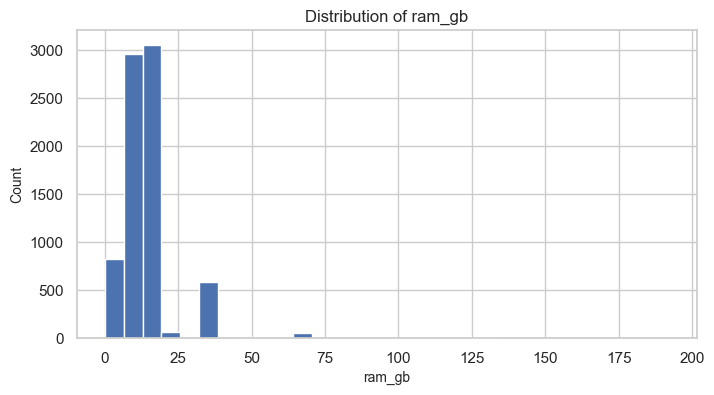

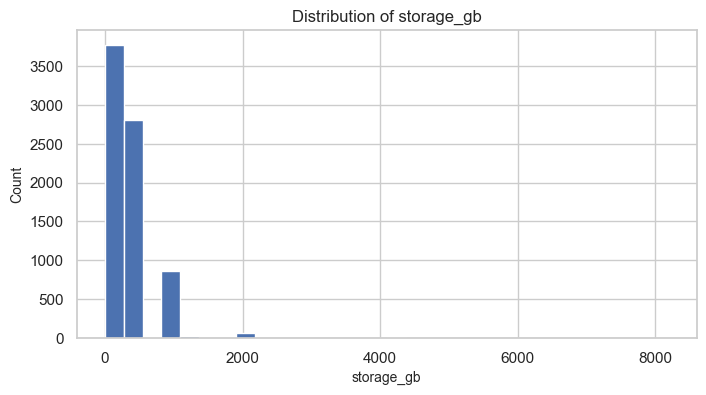

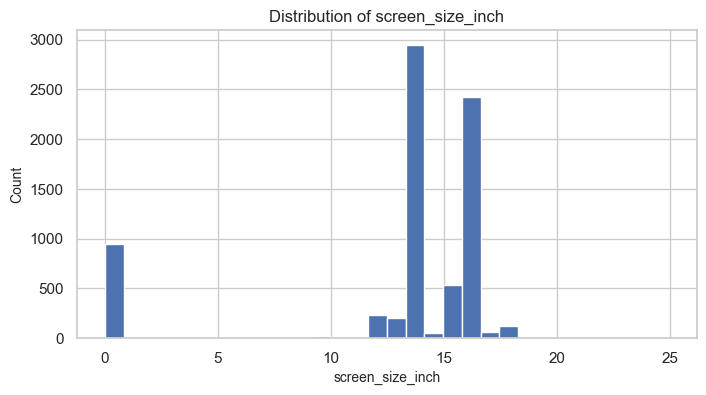

In [338]:
numeric_cols = ["ram_gb", "storage_gb", "screen_size_inch"]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Categorical hóa numeric features theo dạng ordinal

Sau khi quan sát phân phối của ba numeric feature gồm `ram_gb`, `storage_gb` và `screen_size_inch`, có thể thấy các giá trị không phân bố liên tục mà tập trung ở một số mốc phổ biến. Vì vậy, bên cạnh hướng giữ nguyên numeric feature và chuẩn hóa, ta thử thêm hướng rời rạc hóa các numeric feature thành các mức ordinal.

Tuy nhiên, với `ram_gb` và `storage_gb`, các giá trị vẫn có quan hệ thứ tự rõ ràng: RAM lớn hơn hoặc dung lượng lưu trữ lớn hơn thường thể hiện cấu hình cao hơn. Do đó, thay vì chia thành các nhãn rời rạc như `low`, `standard`, `high`, ta mã hóa chúng thành các mức số có thứ tự.

Đối với `ram_gb`, giá trị `0` được giữ là `0`, đại diện cho trường hợp thiếu thông tin. Với các giá trị lớn hơn 0, RAM được chia theo các khoảng lũy thừa của 2. Cụ thể, các giá trị nằm trong khoảng $[2^{i-1}, 2^i]$ sẽ được gán giá trị là `i`. Cách này phù hợp vì RAM laptop thường xuất hiện ở các mức như 4GB, 8GB, 16GB, 32GB và 64GB.

Ví dụ:

```text
0GB  -> 0
4GB  -> 2
8GB  -> 3
16GB -> 4
32GB -> 5
64GB -> 6
```

Đối với `storage_gb`, giá trị 0 được giữ là 0, đại diện cho trường hợp thiếu thông tin. Với các giá trị lớn hơn 0, dung lượng lưu trữ được chia theo các khoảng dựa trên $128 * 2^i$. Cụ thể, các giá trị nằm trong khoảng $[128 * 2^{`i-1}, 128 * 2^i]$ sẽ được gán giá trị là i. Cách này phù hợp vì dung lượng lưu trữ laptop thường xuất hiện ở các mốc như 128GB, 256GB, 512GB, 1TB và 2TB.

Ví dụ:

```
0GB    -> 0
128GB  -> 1
256GB  -> 2
512GB  -> 3
1024GB -> 4
2048GB -> 5
```
Đối với `screen_size_inch`, vì kích thước màn hình không tăng theo cấp số nhân như RAM và storage, ta chia theo các nhóm kích thước phổ biến. Giá trị 0 được giữ là 0, đại diện cho trường hợp thiếu thông tin. Các giá trị còn lại được chia thành các nhóm như màn hình nhỏ, trung bình, tiêu chuẩn và lớn.

Cách mã hóa này giúp biến các numeric feature thành các mức rời rạc nhưng vẫn giữ được quan hệ thứ tự. Vì vậy, các feature mới có thể được sử dụng như ordinal feature trong mô hình.

In [339]:
# Encode numeric features into ordinal levels
def encode_ram_level(x):
    """
    0 -> 0
    [2^(i-1), 2^i] -> i

    Example:
    2GB  -> 1
    4GB  -> 2
    8GB  -> 3
    16GB -> 4
    32GB -> 5
    64GB -> 6
    """
    if pd.isna(x) or x == 0:
        return 0

    x = float(x)
    return int(math.ceil(math.log2(x)))


def encode_storage_level(x):
    if pd.isna(x) or x == 0:
        return 0

    x = float(x)
    if x <= 128:
        return 1

    return int(math.ceil(math.log2(x / 128))) + 1


def encode_screen_size_level(x):
    """
    0 -> 0
    Other values are grouped by common laptop screen sizes.
    """
    if pd.isna(x) or x == 0:
        return 0
    elif x < 14:
        return 1
    elif x < 15.6:
        return 2
    elif x <= 16:
        return 3
    else:
        return 4


df["ram_level"] = df["ram_gb"].apply(encode_ram_level)
df["storage_level"] = df["storage_gb"].apply(encode_storage_level)
df["screen_size_level"] = df["screen_size_inch"].apply(encode_screen_size_level)

In [340]:
level_cols = [
    "ram_level",
    "storage_level",
    "screen_size_level"
]

for col in level_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


ram_level:
ram_level
0     181
1      12
2     602
3    2993
4    3054
5     634
6      77
7      12
8       1
Name: count, dtype: int64

storage_level:
storage_level
0     482
1     727
2    2564
3    2801
4     863
5     113
6      11
7       5
Name: count, dtype: int64

screen_size_level:
screen_size_level
0     950
1    2897
2     633
3    2848
4     238
Name: count, dtype: int64


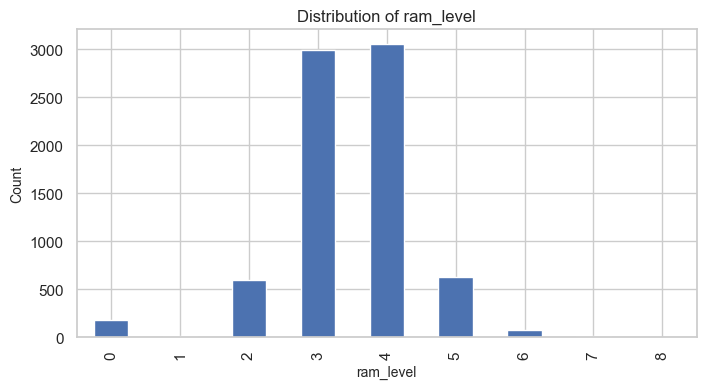

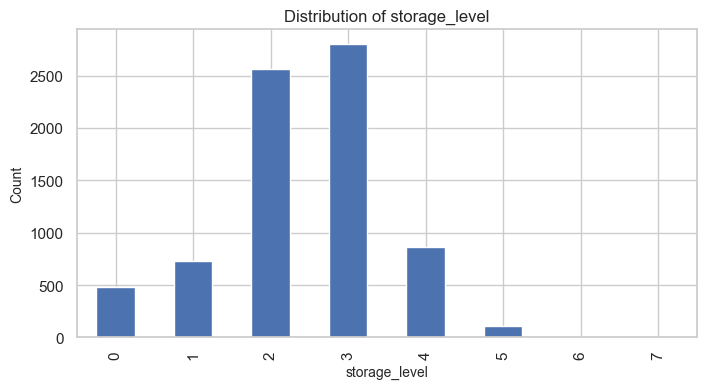

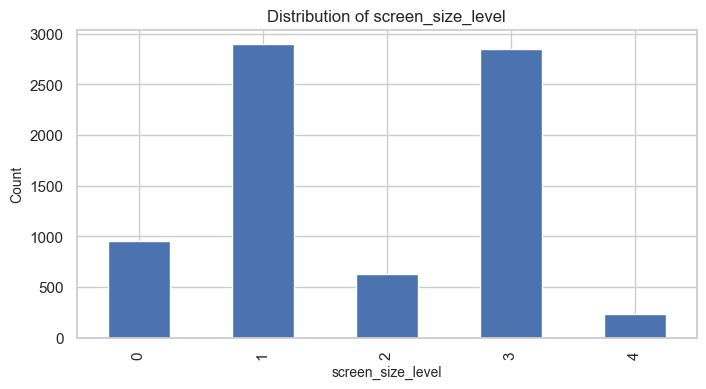

In [341]:
for col in level_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Nhận xét sau khi rời rạc hóa numeric features

Sau khi chuyển ba numeric feature `ram_gb`, `storage_gb` và `screen_size_inch` thành các mức ordinal, có thể thấy các feature mới phản ánh khá rõ các nhóm cấu hình phổ biến của laptop. Các giá trị được mã hóa không còn biểu diễn trực tiếp dung lượng hoặc kích thước gốc, mà biểu diễn cấp độ cấu hình theo thứ tự tăng dần.

Với `ram_level`, dữ liệu tập trung chủ yếu ở level 3 và level 4, tương ứng với các mức RAM phổ biến khoảng 8GB và 16GB. Đây là hai cấu hình RAM xuất hiện nhiều nhất trong tập dữ liệu. Level 5 cũng có số lượng tương đối đáng kể, đại diện cho nhóm RAM khoảng 32GB. Các level cao hơn như 6, 7 và 8 xuất hiện ít hơn, tương ứng với các cấu hình RAM rất cao. Level 0 có 181 dòng, đại diện cho các bản ghi thiếu thông tin RAM đã được fill bằng 0. Nhìn chung, cách mã hóa RAM theo lũy thừa của 2 là phù hợp vì RAM laptop thường tăng theo các mốc 4GB, 8GB, 16GB, 32GB và 64GB.

Với `storage_level`, dữ liệu tập trung chủ yếu ở level 2 và level 3, tương ứng với các mức dung lượng phổ biến khoảng 256GB và 512GB. Level 4, tương ứng với khoảng 1TB, cũng xuất hiện với số lượng đáng kể. Level 1 đại diện cho nhóm dung lượng thấp hơn hoặc bằng 128GB, trong khi level 0 đại diện cho các bản ghi thiếu thông tin storage. Các level cao hơn như 5, 6 và 7 xuất hiện ít hơn, tương ứng với các mức storage rất cao như 2TB, 4TB hoặc cao hơn. Cách mã hóa storage theo các mốc `128 * 2^i` giúp giữ lại các đỉnh quan trọng của phân phối như 128GB, 256GB, 512GB và 1TB, đồng thời tránh tạo ra quá nhiều level lẻ như khi chia tuyến tính theo từng khoảng 128GB.

Với `screen_size_level`, dữ liệu tập trung chủ yếu ở level 1 và level 3. Level 1 tương ứng với nhóm màn hình nhỏ hơn 14 inch, còn level 3 tương ứng với nhóm màn hình phổ biến khoảng 15.6 đến 16 inch. Level 2 có số lượng ít hơn, đại diện cho nhóm màn hình trung bình từ 14 đến dưới 15.6 inch. Level 4 xuất hiện ít nhất, đại diện cho các màn hình lớn hơn 16 inch. Level 0 có 950 dòng, cho thấy số lượng bản ghi thiếu thông tin màn hình tương đối nhiều. Cách chia nhóm màn hình hiện tại phù hợp vì kích thước màn hình laptop thường tập trung quanh một số nhóm phổ biến, thay vì tăng theo cấp số nhân như RAM hoặc storage.

Tóm lại, cách rời rạc hóa này giúp giữ được quan hệ thứ tự của các feature, đồng thời chuyển các giá trị numeric gốc thành các cấp độ cấu hình dễ diễn giải hơn. `ram_level`, `storage_level` và `screen_size_level` đều có phân phối tương đối hợp lý. Đặc biệt, `storage_level` sau khi mã hóa theo mốc lũy thừa của 2 trở nên gọn hơn, giữ được các mức dung lượng phổ biến và giảm bớt các level hiếm không cần thiết. Do đó, các feature dạng level này có thể được sử dụng như ordinal features trong quá trình huấn luyện mô hình.

Ở notebook này, quá trình feature engineering dừng lại ở bước tạo ordinal features. Việc chuẩn hóa bằng MinMaxScaler hoặc các phương pháp scaling khác không được thực hiện tại đây để tránh phụ thuộc vào toàn bộ dữ liệu trước khi chia train/test. Scaling sẽ được xử lý ở bước huấn luyện mô hình, bên trong pipeline tương ứng với từng loại model. Điều này giúp tránh data leakage và cho phép linh hoạt lựa chọn preprocessing phù hợp với từng mô hình.

# 5. Feature Engineering - Categorical Features

In [342]:
for col in cat_cols:
    print(f"\n===== {col} =====")
    
    counts = df[col].value_counts(dropna=False)
    ratios = df[col].value_counts(normalize=True, dropna=False).round(4)
    
    summary = pd.DataFrame({
        "count": counts,
        "ratio": ratios
    })
    
    print(summary)


===== brand_grouped =====
               count  ratio
brand_grouped              
Dell            2117  0.280
Lenovo          1104  0.146
Apple           1023  0.135
HP               962  0.127
ASUS             893  0.118
Acer             496  0.066
MSI              320  0.042
Other            306  0.040
Microsoft        250  0.033
Sony              30  0.004
Toshiba           26  0.003
LG                25  0.003
Gigabyte          14  0.002

===== model_grouped =====
                    count  ratio
model_grouped                   
Other                4841  0.640
Latitude              462  0.061
MacBook Pro           318  0.042
Precision             195  0.026
MacBook Air           179  0.024
Inspiron              159  0.021
ThinkPad              106  0.014
Elitebook              95  0.013
Nitro 5                89  0.012
ProBook                89  0.012
MacBook Pro M1         86  0.011
MacBook Air M1         82  0.011
Vostro                 75  0.010
ThinkPad X1 Carbon     65  0.00

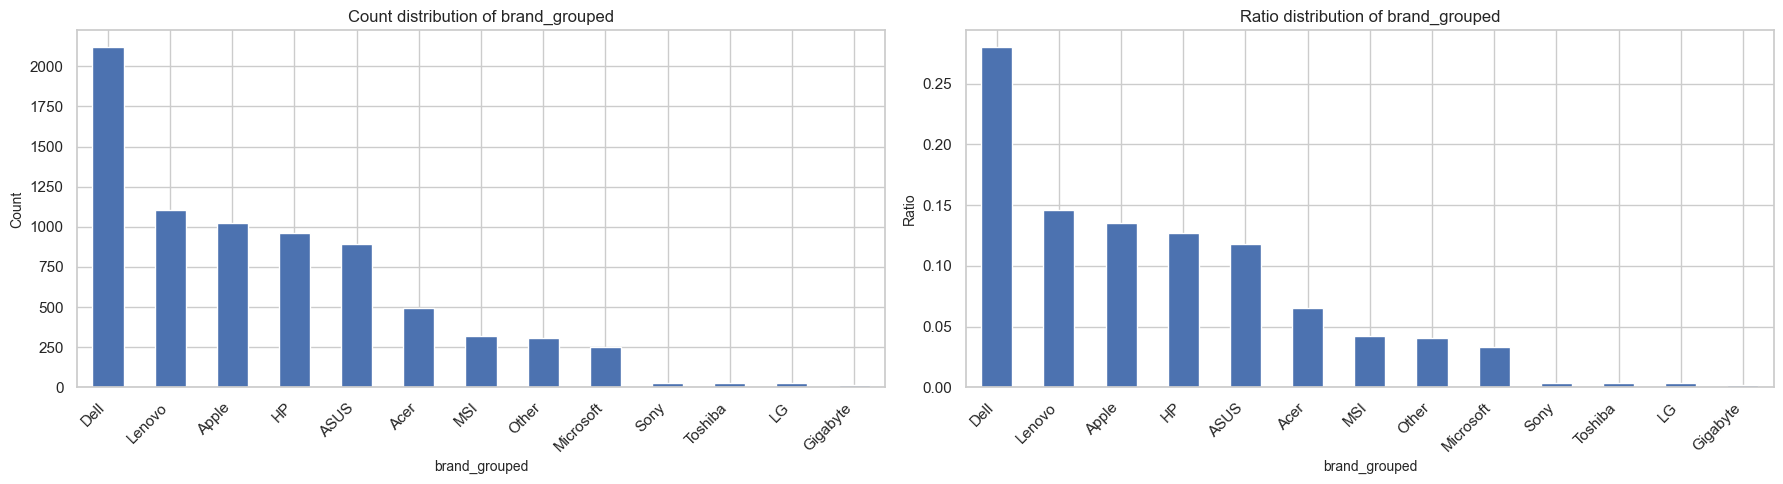

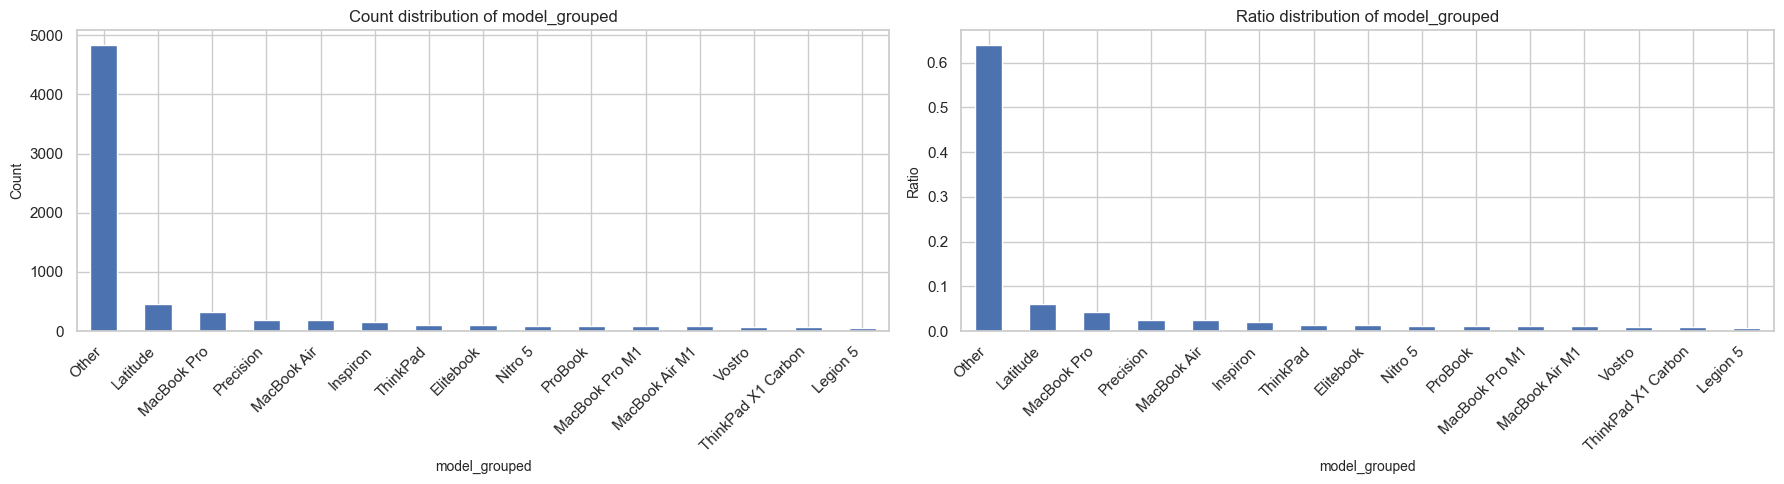

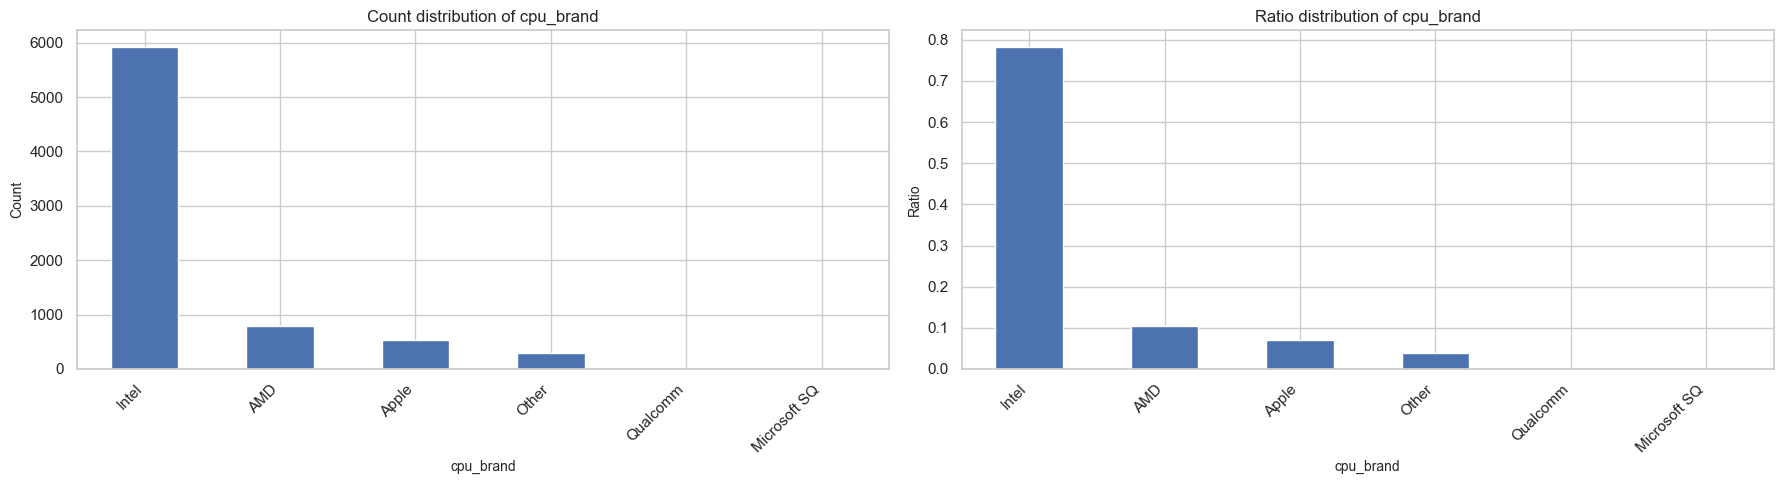

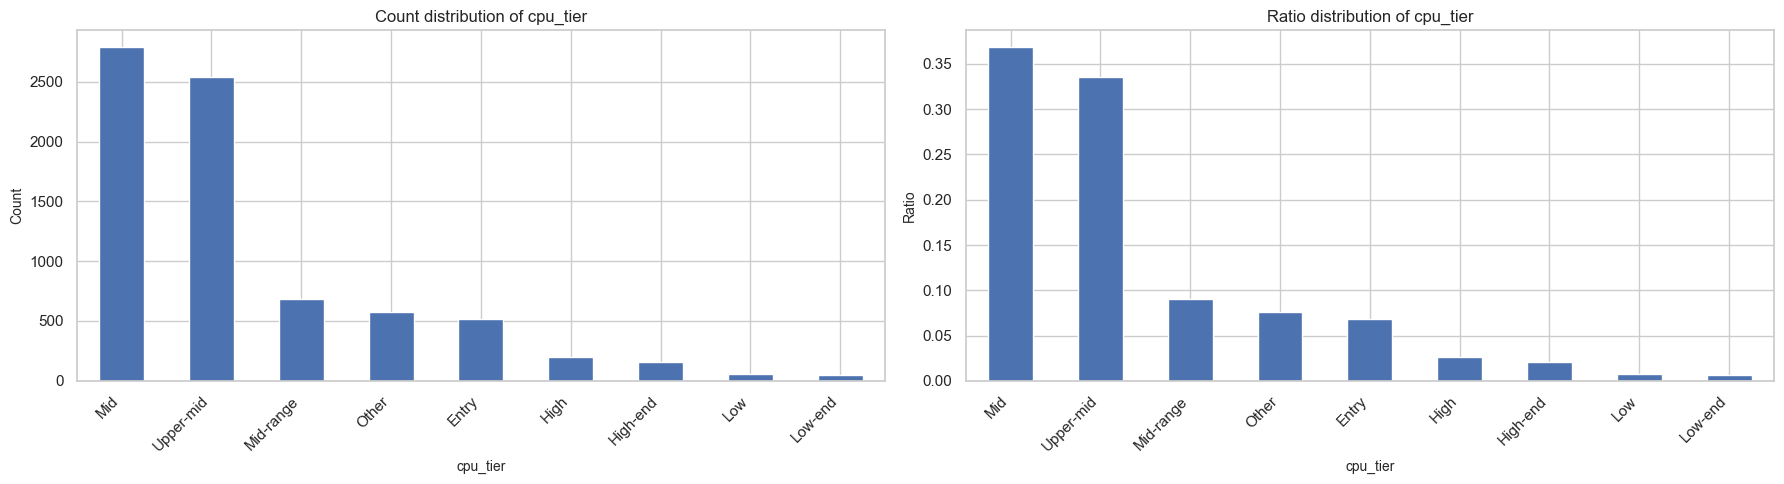

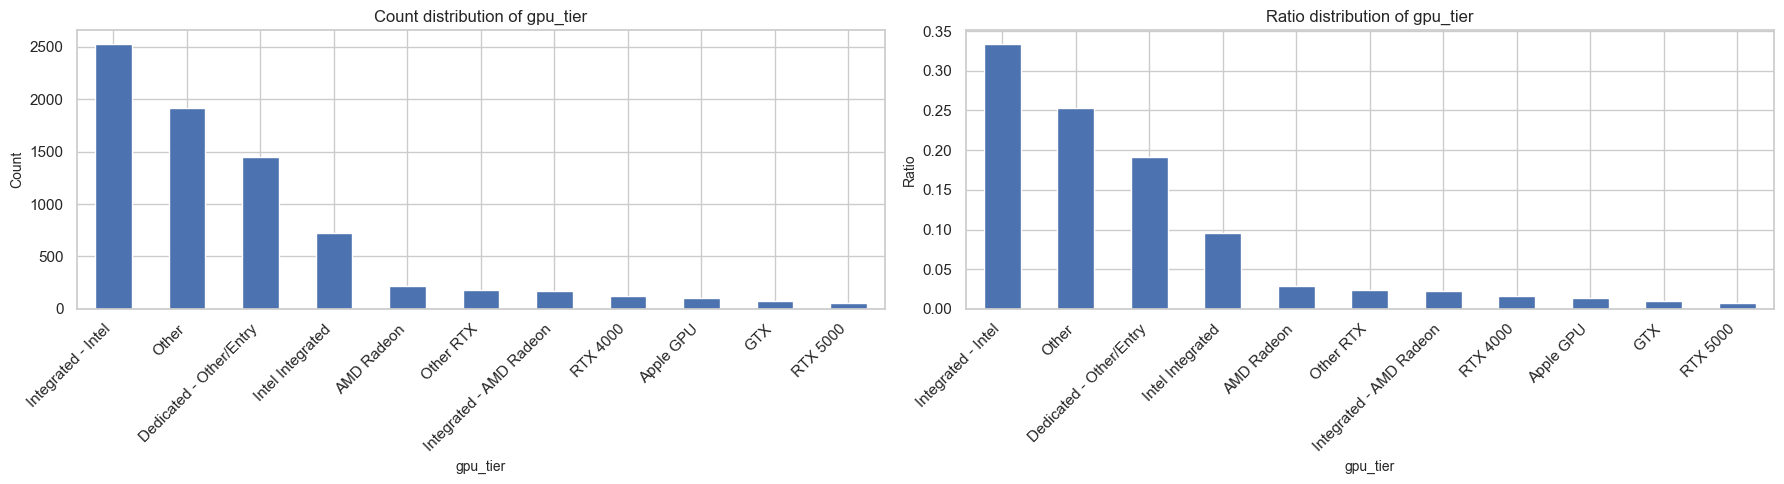

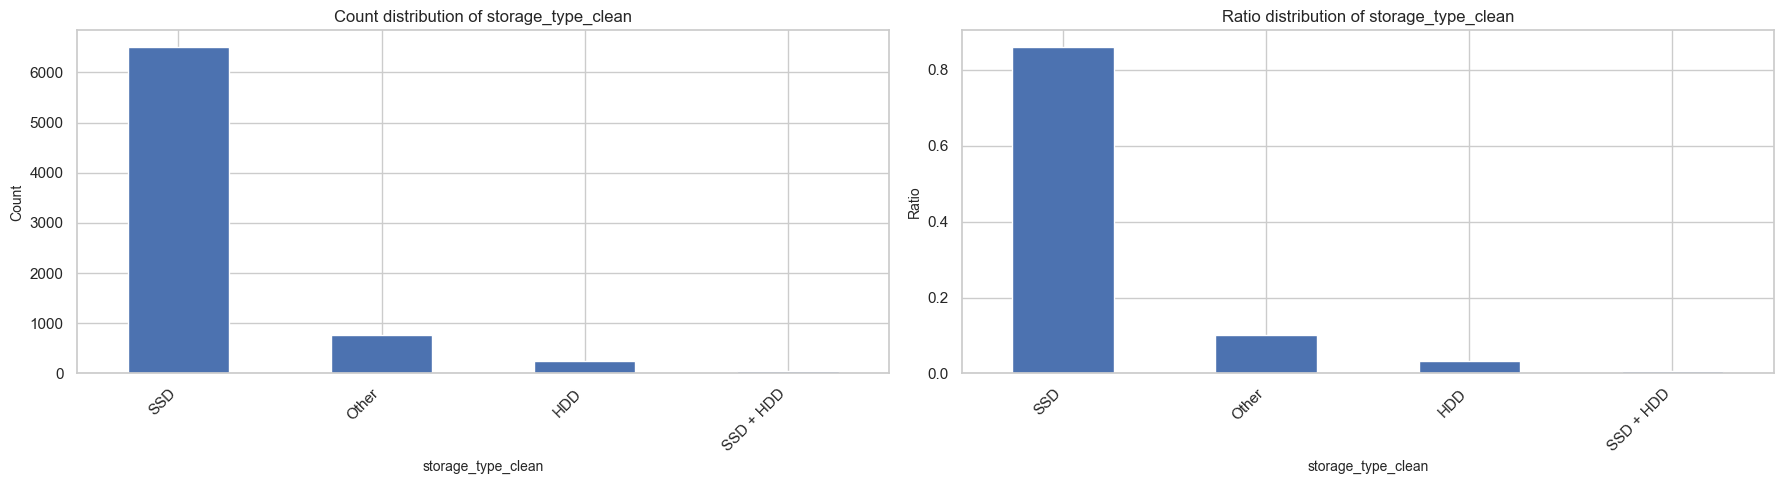

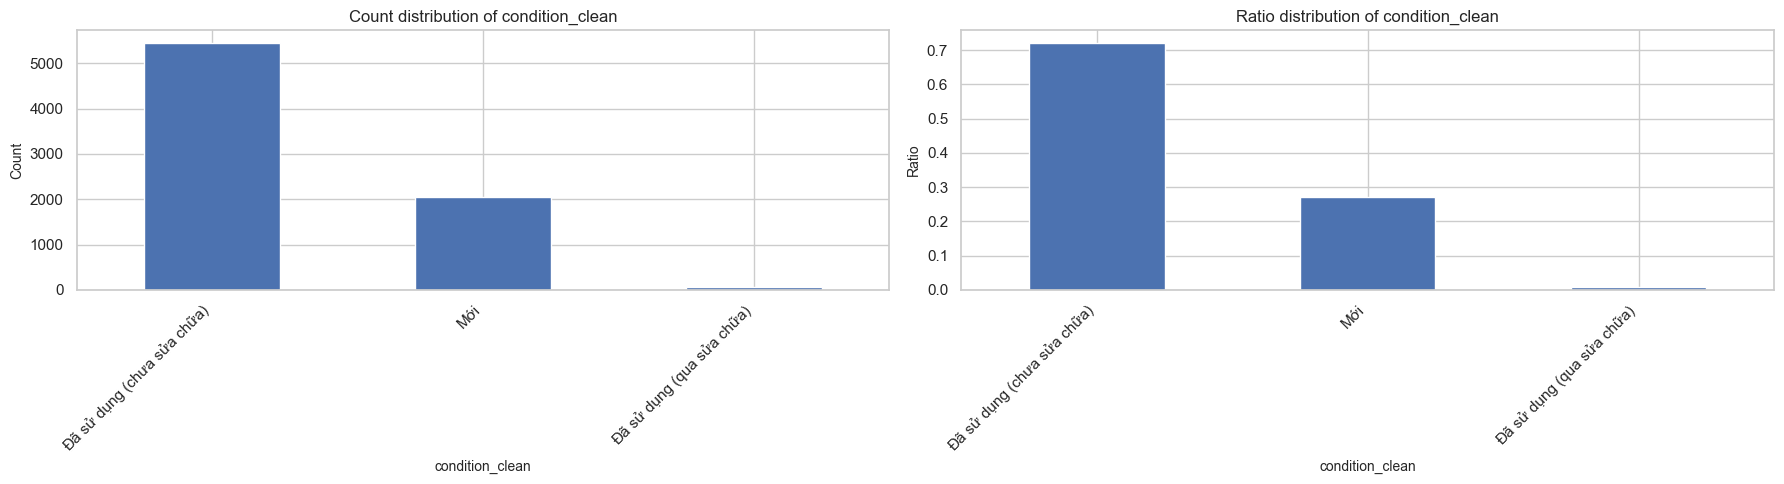

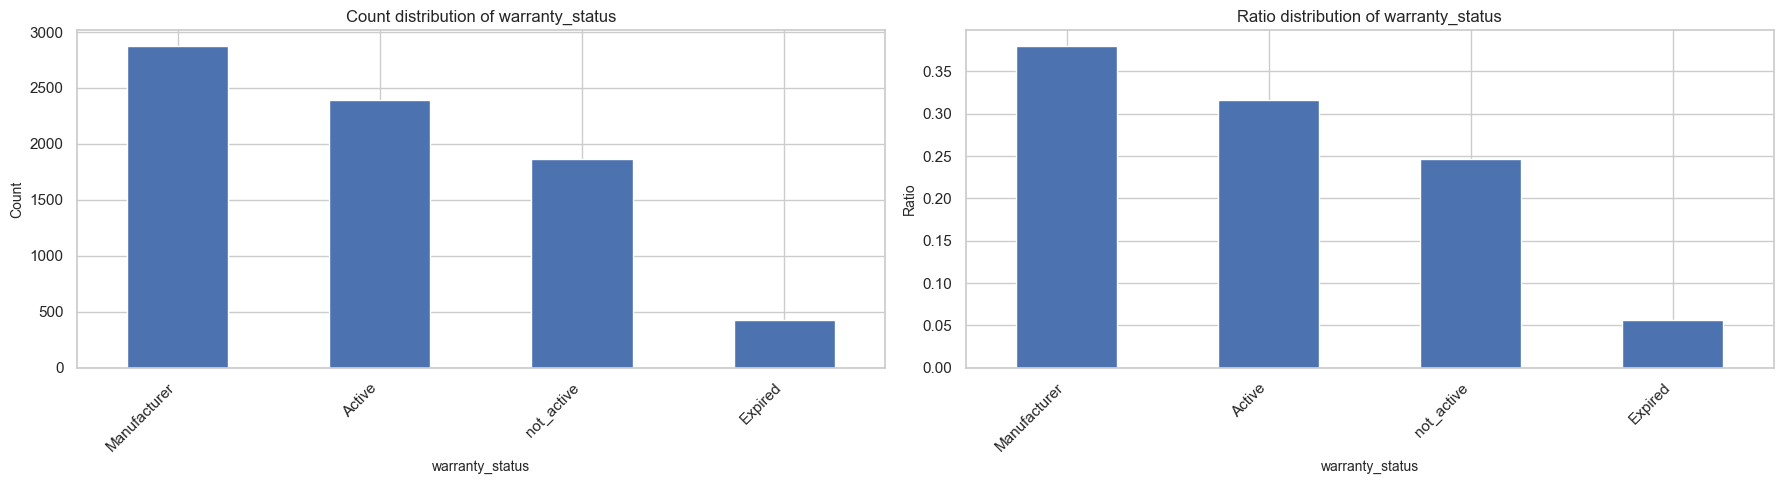

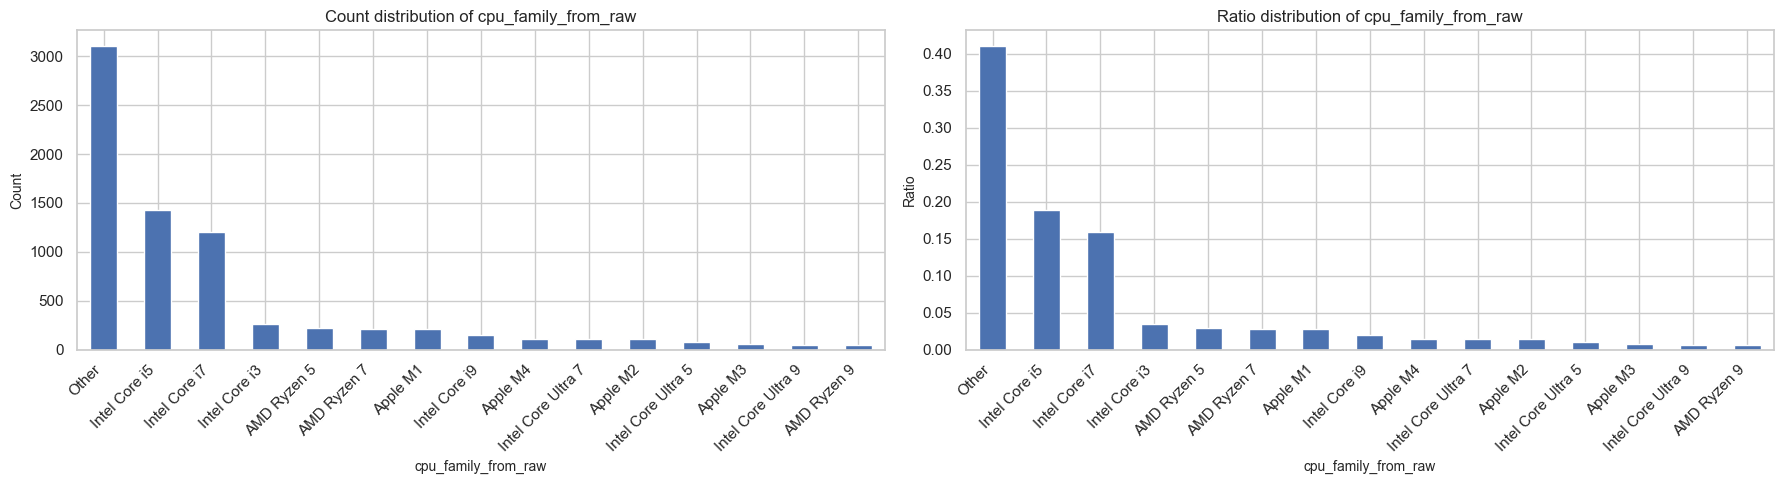

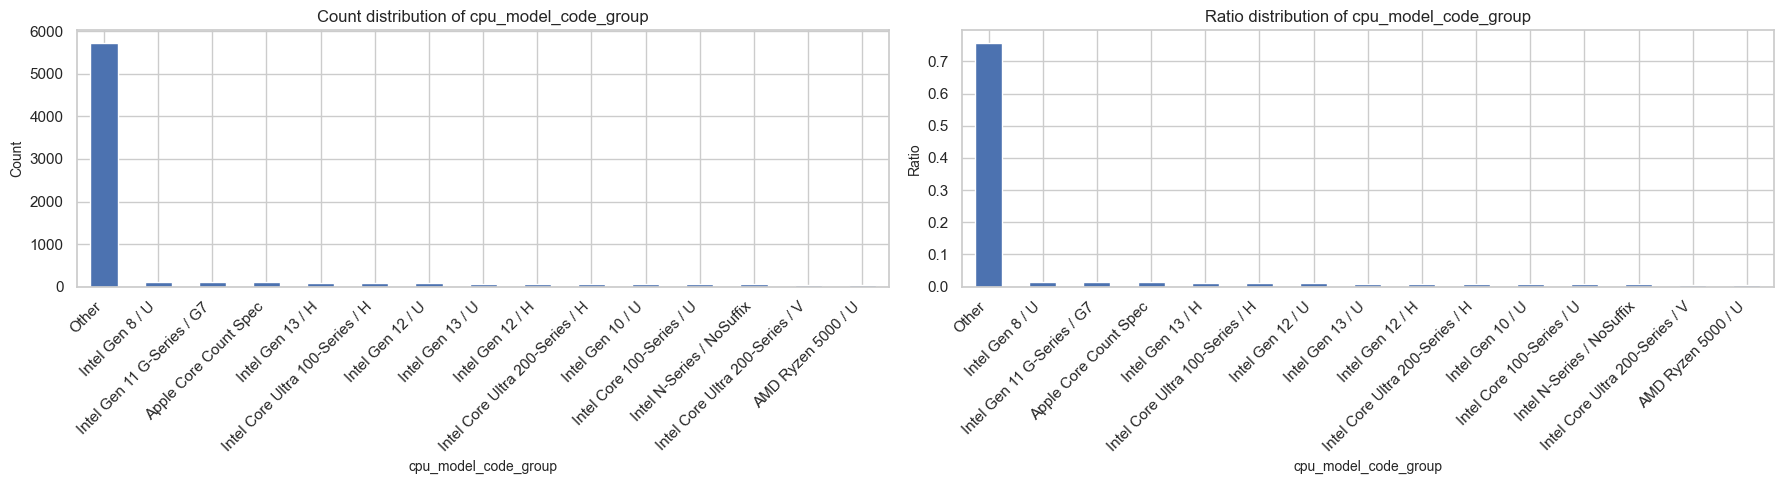

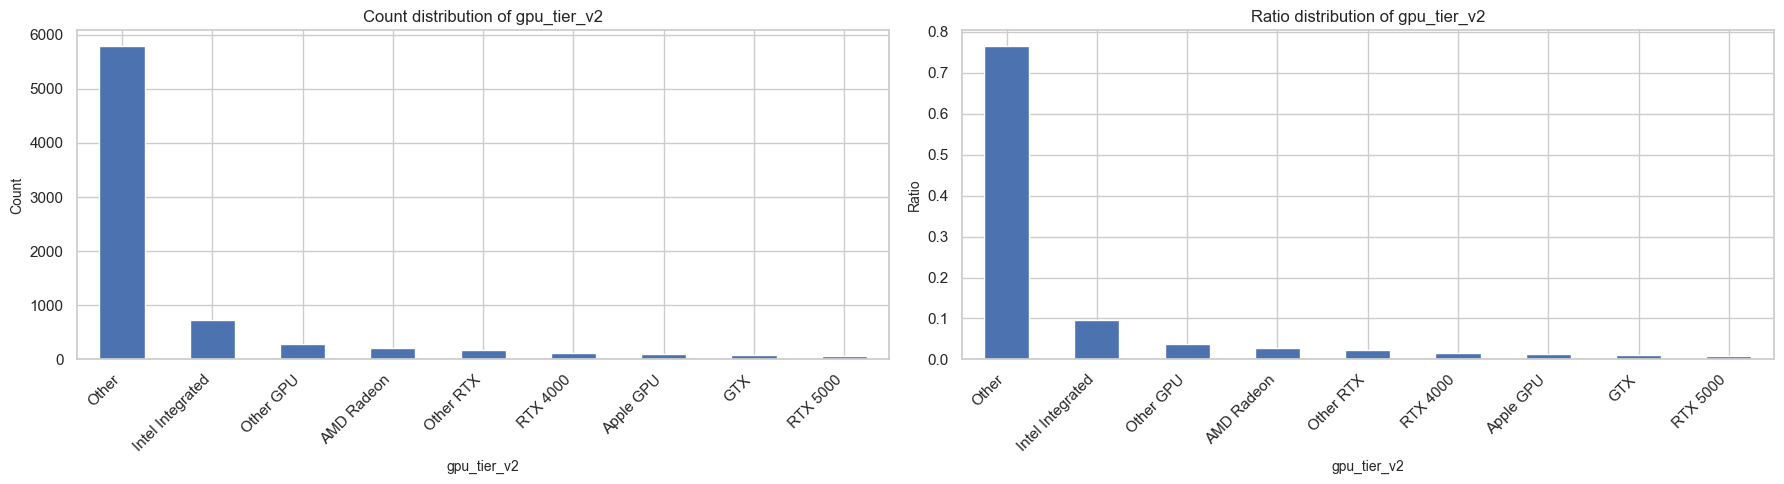

In [343]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    count_data = df[col].value_counts(dropna=False).head(15)
    ratio_data = df[col].value_counts(normalize=True, dropna=False).head(15)

    count_data.plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Count distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    ratio_data.plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Ratio distribution of {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Ratio")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
        for label in ax.get_xticklabels():
            label.set_ha("right")

    plt.tight_layout()
    plt.show()

<Figure size 1200x500 with 0 Axes>

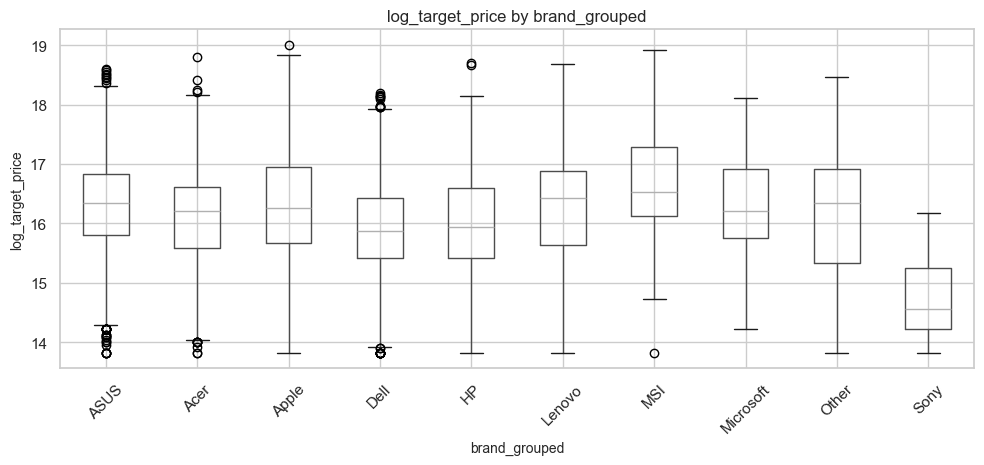

<Figure size 1200x500 with 0 Axes>

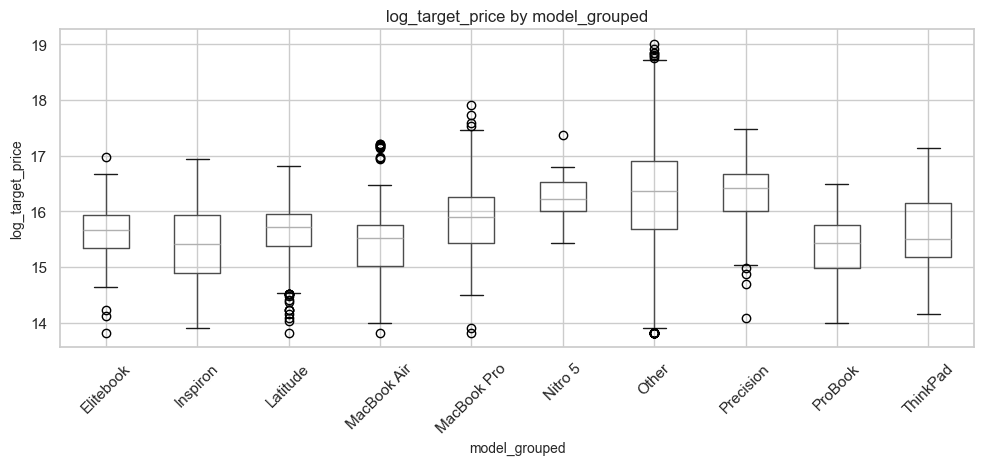

<Figure size 1200x500 with 0 Axes>

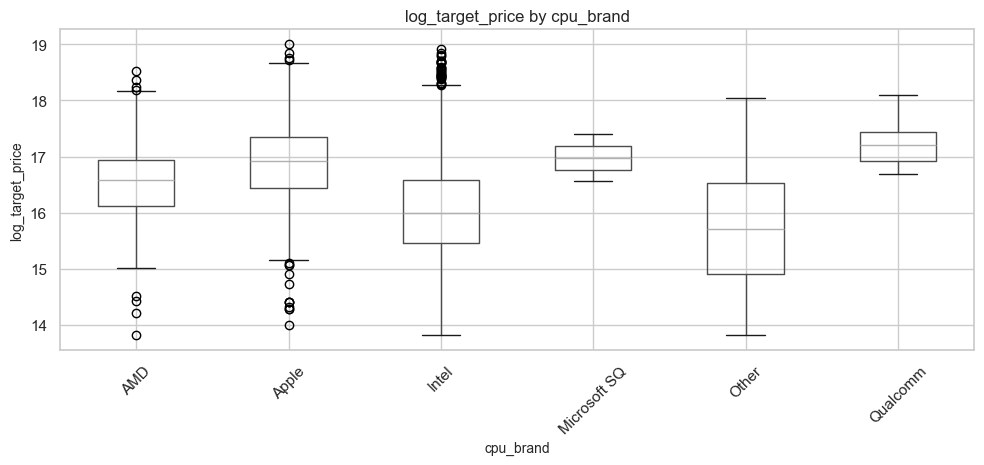

<Figure size 1200x500 with 0 Axes>

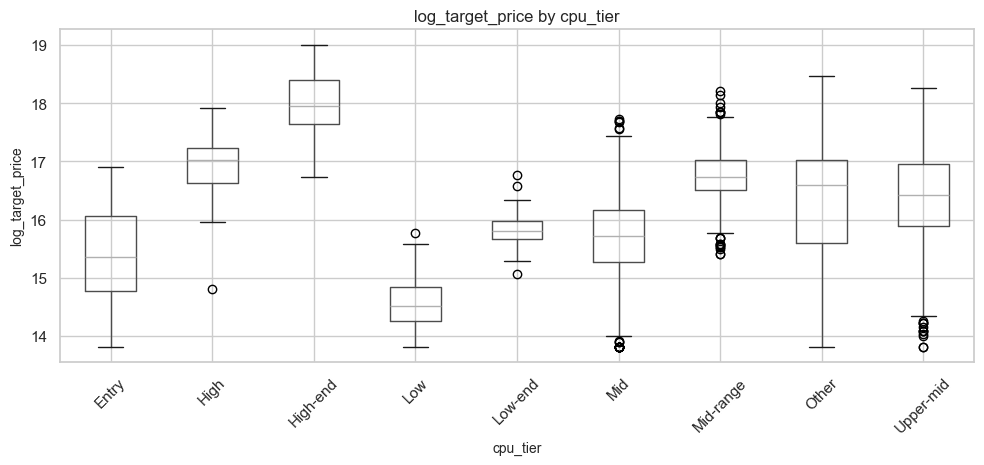

<Figure size 1200x500 with 0 Axes>

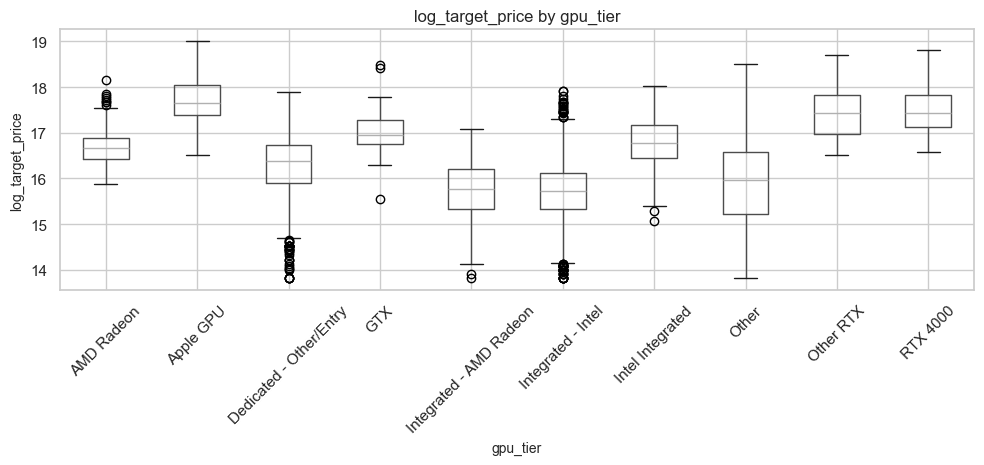

<Figure size 1200x500 with 0 Axes>

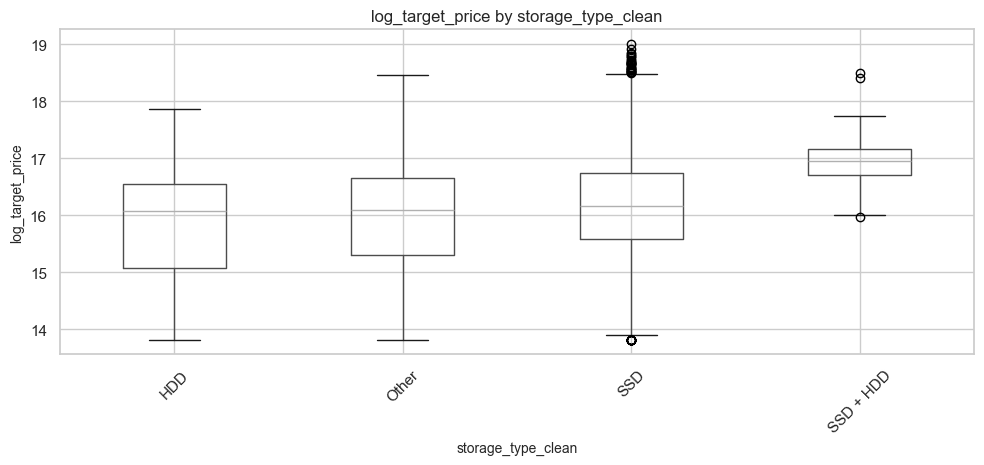

<Figure size 1200x500 with 0 Axes>

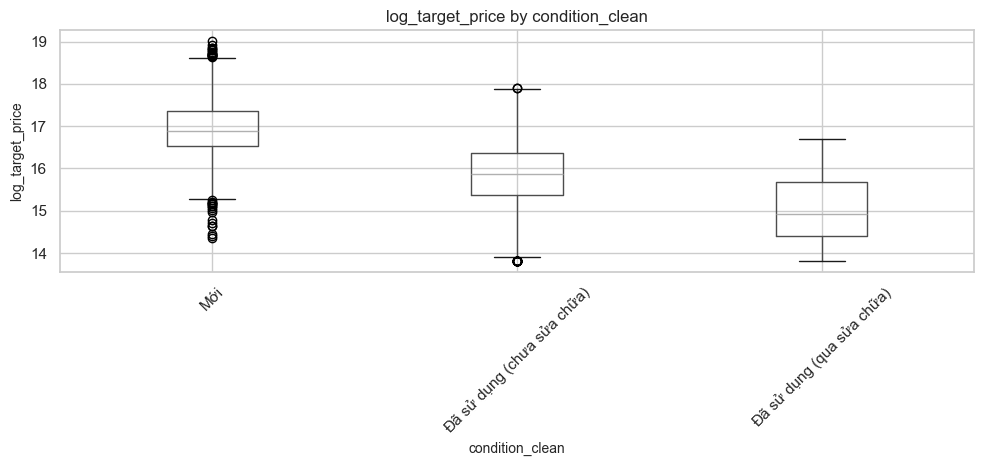

<Figure size 1200x500 with 0 Axes>

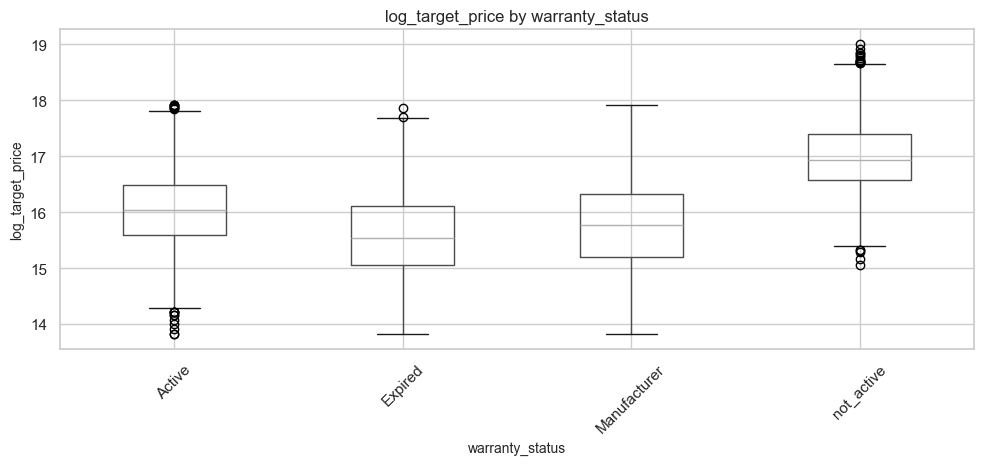

<Figure size 1200x500 with 0 Axes>

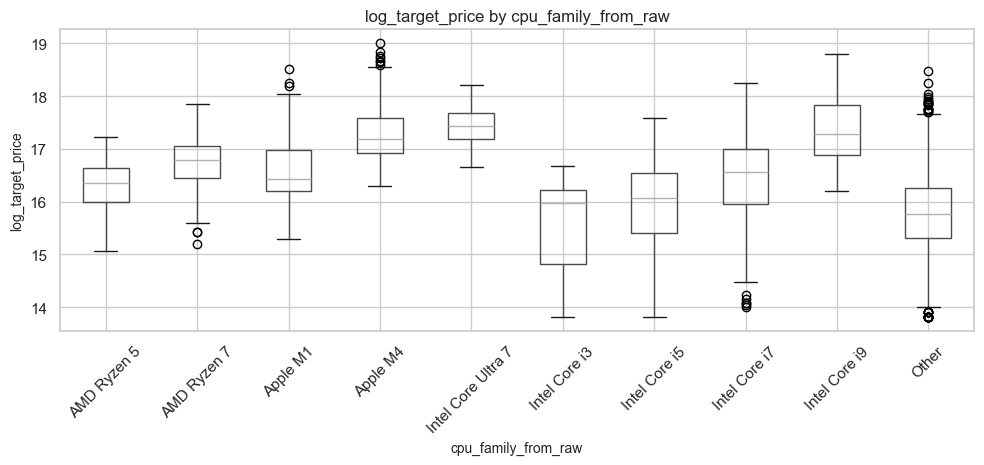

<Figure size 1200x500 with 0 Axes>

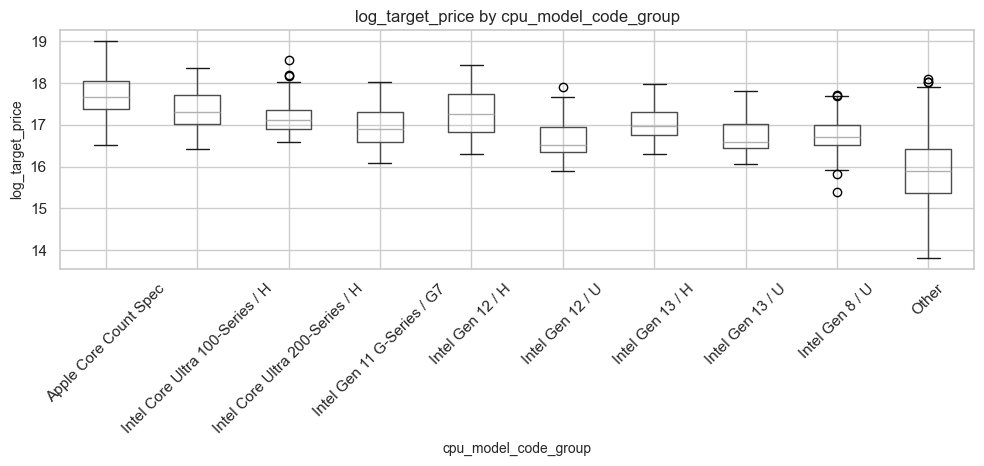

<Figure size 1200x500 with 0 Axes>

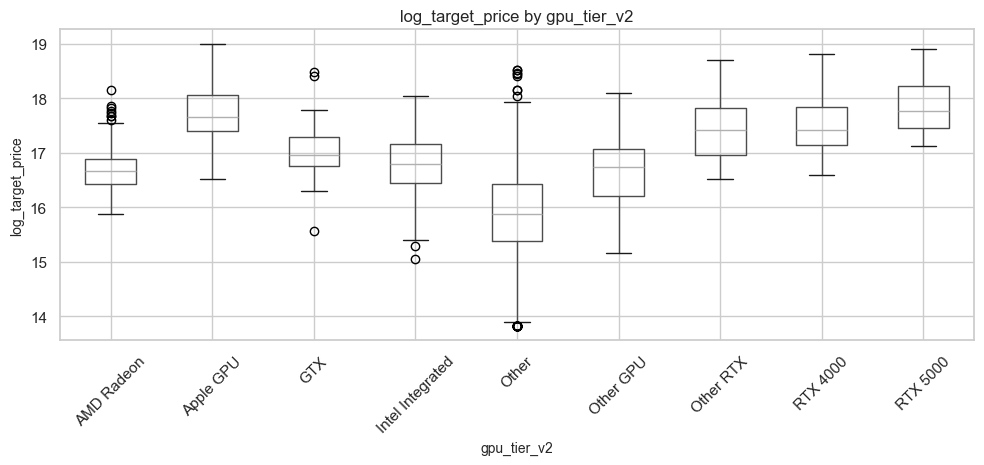

In [344]:
for col in cat_cols:
    top_categories = df[col].value_counts().head(10).index
    temp = df[df[col].isin(top_categories)]

    plt.figure(figsize=(12, 5))
    temp.boxplot(column="log_target_price", by=col, rot=45)
    plt.title(f"log_target_price by {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel("log_target_price")
    plt.tight_layout()
    plt.show()

,feature,rare_category_count,rare_total_ratio
9,cpu_model_code_group,94,0.177
1,model_grouped,20,0.114
8,cpu_family_from_raw,21,0.050
3,cpu_tier,2,0.014
0,brand_grouped,4,0.013
6,condition_clean,1,0.008
4,gpu_tier,1,0.008
10,gpu_tier_v2,1,0.008
5,storage_type_clean,1,0.005
2,cpu_brand,2,0.004


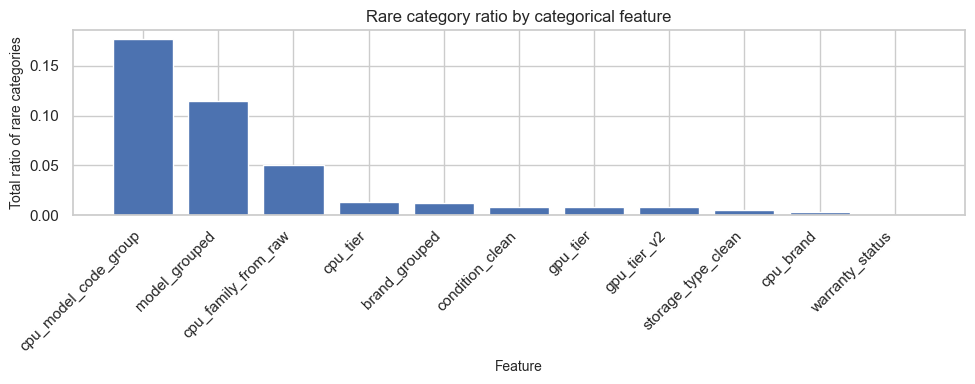

In [345]:
rare_summary = []

for col in cat_cols:
    freq = df[col].value_counts(normalize=True, dropna=False)
    rare_ratio = freq[freq < 0.01].sum()
    rare_count = (freq < 0.01).sum()

    rare_summary.append({
        "feature": col,
        "rare_category_count": rare_count,
        "rare_total_ratio": rare_ratio
    })

rare_summary = pd.DataFrame(rare_summary).sort_values("rare_total_ratio", ascending=False)
display(rare_summary)

plt.figure(figsize=(10, 4))
plt.bar(rare_summary["feature"], rare_summary["rare_total_ratio"])
plt.title("Rare category ratio by categorical feature")
plt.xlabel("Feature")
plt.ylabel("Total ratio of rare categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Phân tích rare category cho thấy hầu hết các biến categorical có tỷ lệ nhóm hiếm khá thấp. 
Biến `model_grouped` có tỷ lệ rare category cao nhất, khoảng 11.4%, với 20 category hiếm. 
Điều này cho thấy tên model laptop khá đa dạng và phân tán, vì vậy việc gom các model hiếm vào nhóm "Other" là cần thiết để giảm nhiễu và tránh overfitting.

Các biến còn lại như `cpu_tier`, `brand_grouped`, `condition_clean`, `gpu_tier`, `storage_type_clean`, và `cpu_brand` đều có tỷ lệ rare category thấp, dưới 1.5%. 
Riêng `warranty_status` không có rare category, cho thấy các nhóm trong biến này được phân bố khá ổn định.

Phân tích rare category cho thấy hầu hết các biến categorical có tỷ lệ nhóm hiếm khá thấp. 
Biến `model_grouped` có tỷ lệ rare category cao nhất, khoảng 11.4%, với 20 category hiếm. 
Điều này cho thấy tên model laptop khá đa dạng và phân tán, vì vậy việc gom các model hiếm vào nhóm "Other" là cần thiết để giảm nhiễu và tránh overfitting.

Các biến còn lại như `cpu_tier`, `brand_grouped`, `condition_clean`, `gpu_tier`, `storage_type_clean`, và `cpu_brand` đều có tỷ lệ rare category thấp, dưới 1.5%. 
Riêng `warranty_status` không có rare category, cho thấy các nhóm trong biến này được phân bố khá ổn định.

In [346]:
# SSD       → storage_ssd=1, storage_hdd=0, no_info_storage=0
# HDD       → storage_ssd=0, storage_hdd=1, no_info_storage=0
# SSD + HDD → storage_ssd=1, storage_hdd=1, no_info_storage=0
# Other     → storage_ssd=0, storage_hdd=0, no_info_storage=1

df["storage_ssd"] = df["storage_type_clean"].isin(["SSD", "SSD + HDD"]).astype(int)
df["storage_hdd"] = df["storage_type_clean"].isin(["HDD", "SSD + HDD"]).astype(int)
df["no_info_storage"] = df["storage_type_clean"].eq("Other").astype(int)

In [347]:
condition_map = {
    "Đã sử dụng (qua sửa chữa)": 1,
    "Đã sử dụng (chưa sửa chữa)": 2,
    "Mới": 3
}

df["condition_score"] = df["condition_clean"].map(condition_map)
df["condition_score"] = df["condition_score"].fillna(2)

In [348]:
warranty_map = {
    "Expired": 0,
    "Active": 1,
    "Manufacturer": 1,
    "not_active": 2
}

df["warranty_encoded"] = df["warranty_status"].map(warranty_map)

In [349]:
# Các cặp feature và cột no_info tương ứng
check_pairs = {
    "brand_grouped": "no_info_brand",
    "model_grouped": "no_info_model",
    "cpu_brand": "no_info_cpu_brand",
    "cpu_tier": "no_info_cpu_tier",
    "gpu_tier": "no_info_gpu",
}

# Các giá trị được xem là không có thông tin
no_info_values = ["other", "unknown", "missing", "orther"]

for feature_col, no_info_col in check_pairs.items():
    print(f"\n===== Kiểm tra {feature_col} -> {no_info_col} =====")

    # Chuẩn hóa text: bỏ khoảng trắng và chuyển về chữ thường
    feature_clean = df[feature_col].astype("string").str.strip().str.lower()

    # Điều kiện feature thuộc nhóm no_info
    condition_other = feature_clean.isin(no_info_values)

    # Điều kiện no_info phải bằng 1
    condition_no_info_true = df[no_info_col].eq(1)

    # Kiểm tra các dòng feature là Other/Unknown/Missing nhưng no_info không bằng 1
    wrong_rows = df[condition_other & ~condition_no_info_true]

    if wrong_rows.empty:
        print("Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1")
    else:
        print("Sai: có dòng Other/Unknown/Missing nhưng no_info != 1")
        print("Số dòng sai:", len(wrong_rows))
        display(wrong_rows[[feature_col, no_info_col]].head(20))


===== Kiểm tra brand_grouped -> no_info_brand =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra model_grouped -> no_info_model =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra cpu_brand -> no_info_cpu_brand =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra cpu_tier -> no_info_cpu_tier =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra gpu_tier -> no_info_gpu =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1


## Encode Brand, Model và CPU

Trước khi đưa dữ liệu vào mô hình, các cột dạng chữ cần được chuyển sang dạng số. Trong phần này, các cột được xử lý gồm `brand_grouped`, `model_grouped`, `cpu_brand` và `cpu_tier`.

### Brand

Cột `brand_grouped` thể hiện thương hiệu laptop như Dell, Lenovo, Apple, HP, ASUS hoặc Other. Đây là biến phân loại không có thứ tự, vì vậy nên sử dụng One-Hot Encoding. Cách này giúp mỗi thương hiệu được biểu diễn thành một cột riêng, tránh việc mô hình hiểu nhầm rằng các hãng có quan hệ lớn nhỏ với nhau.

### Model

Cột `model_grouped` thể hiện dòng máy hoặc model laptop như Latitude, MacBook Pro, ThinkPad, Inspiron hoặc Other. Cột này cũng là biến phân loại không có thứ tự, nên phù hợp với One-Hot Encoding. Việc encode giúp mô hình nhận biết từng nhóm model mà không tạo ra thứ tự giả giữa các model.

### CPU Brand

Cột `cpu_brand` thể hiện hãng CPU như Intel, AMD, Apple, Qualcomm, Microsoft SQ hoặc Other. Đây cũng là biến phân loại không có thứ tự, nên sử dụng One-Hot Encoding. Như vậy, mỗi hãng CPU sẽ được tách thành một đặc trưng riêng để mô hình xử lý tốt hơn.

### CPU Tier

Cột `cpu_tier` thể hiện phân khúc hiệu năng của CPU, ví dụ Low-end, Low, Entry, Mid-range, Mid, Upper-mid, High và High-end. Khác với brand và model, cột này có thứ tự từ thấp đến cao, nên có thể sử dụng Ordinal Encoding. Các mức CPU sẽ được chuyển thành số theo thứ tự hiệu năng tăng dần.

In [350]:
# Encode cpu_tier bằng Ordinal Encoding
cpu_tier_map = {
    "Other": 0,
    "Low-end": 1,
    "Low": 2,
    "Entry": 3,
    "Mid-range": 4,
    "Mid": 5,
    "Upper-mid": 6,
    "High": 7,
    "High-end": 8
}

df["cpu_tier_encoded"] = df["cpu_tier"].map(cpu_tier_map)

# Kiểm tra giá trị cpu_tier chưa được map
print("Các giá trị cpu_tier chưa được map:")
print(df[df["cpu_tier_encoded"].isna()]["cpu_tier"].unique())

# One-Hot Encoding cho các biến không có thứ tự
onehot_cols = [
    "brand_grouped",
    "model_grouped",
    "cpu_brand"
]

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    prefix=["brand", "model", "cpu_brand"],
    dtype=int
)

Các giá trị cpu_tier chưa được map:
[]


# CPU

In [351]:
CPU_FEATURES = [
    "cpu_family_from_raw",
    "cpu_model_code_group"
]

TOP_N = 20

for col in CPU_FEATURES:
    print(f"\n{'='*80}")
    print(f"Top values for: {col}")
    print(f"{'='*80}")

    value_counts = (
        df[col]
        .fillna("__MISSING__")
        .astype(str)
        .value_counts()
        .head(TOP_N)
        .reset_index()
    )

    value_counts.columns = [col, "count"]
    value_counts["pct"] = value_counts["count"] / len(df) * 100

    display(value_counts)


Top values for: cpu_family_from_raw


,cpu_family_from_raw,count,pct
0,Other,3110,41.105
1,Intel Core i5,1427,18.861
2,Intel Core i7,1199,15.847
3,Intel Core i3,266,3.516
4,AMD Ryzen 5,216,2.855
5,AMD Ryzen 7,210,2.776
6,Apple M1,206,2.723
7,Intel Core i9,146,1.930
8,Apple M4,111,1.467
9,Intel Core Ultra 7,109,1.441



Top values for: cpu_model_code_group


,cpu_model_code_group,count,pct
0,Other,5738,75.839
1,Intel Gen 8 / U,116,1.533
2,Intel Gen 11 G-Series / G7,111,1.467
3,Apple Core Count Spec,104,1.375
4,Intel Gen 13 / H,81,1.071
5,Intel Core Ultra 100-Series / H,79,1.044
6,Intel Gen 12 / U,72,0.952
7,Intel Gen 13 / U,66,0.872
8,Intel Gen 12 / H,61,0.806
9,Intel Core Ultra 200-Series / H,60,0.793


In [352]:
# ============================================================
# CPU FAMILY GROUPING + ENCODING
# Không giữ cpu_family_group_Unknown vì cpu_brand đã có Other
# Output thêm trực tiếp vào df
# ============================================================

CPU_FAMILY_RAW_COL = "cpu_family_from_raw"

# ------------------------------------------------------------
# 1. Clean raw CPU family text
# ------------------------------------------------------------

df["cpu_family_raw_clean"] = (
    df[CPU_FAMILY_RAW_COL]
    .astype("string")
    .str.strip()
    .fillna("Other")
)

# ------------------------------------------------------------
# 2. Group CPU family
# ------------------------------------------------------------

CPU_FAMILY_GROUP_MAP = {
    # Intel Core i-series
    "Intel Core i3": "Intel Core i",
    "Intel Core i5": "Intel Core i",
    "Intel Core i7": "Intel Core i",
    "Intel Core i9": "Intel Core i",

    # Intel Core Ultra
    "Intel Core Ultra 5": "Intel Core Ultra",
    "Intel Core Ultra 7": "Intel Core Ultra",
    "Intel Core Ultra 9": "Intel Core Ultra",

    # Intel low-end
    "Intel Pentium": "Intel Low End",
    "Intel N-Series": "Intel Low End",
    "Intel Celeron": "Intel Low End",

    # AMD Ryzen
    "AMD Ryzen 3": "AMD Ryzen",
    "AMD Ryzen 5": "AMD Ryzen",
    "AMD Ryzen 7": "AMD Ryzen",
    "AMD Ryzen 9": "AMD Ryzen",
    "AMD Ryzen AI": "AMD Ryzen",

    # Apple Silicon
    "Apple M1": "Apple Silicon",
    "Apple M2": "Apple Silicon",
    "Apple M3": "Apple Silicon",
    "Apple M4": "Apple Silicon",
    "Apple M5": "Apple Silicon",

    # Unknown
    "Other": "Unknown",
}

df["cpu_family_group"] = (
    df["cpu_family_raw_clean"]
    .map(CPU_FAMILY_GROUP_MAP)
    .fillna("Unknown")
)

# ------------------------------------------------------------
# 3. Ordinal level
# ------------------------------------------------------------

CPU_FAMILY_LEVEL_MAP = {
    "Other": -1,

    # Intel low-end
    "Intel Pentium": 0,
    "Intel N-Series": 0,
    "Intel Celeron": 0,

    # Intel Core i
    "Intel Core i3": 1,
    "Intel Core i5": 2,
    "Intel Core i7": 3,
    "Intel Core i9": 4,

    # Intel Core Ultra
    "Intel Core Ultra 5": 2,
    "Intel Core Ultra 7": 3,
    "Intel Core Ultra 9": 4,

    # AMD Ryzen
    "AMD Ryzen 3": 1,
    "AMD Ryzen 5": 2,
    "AMD Ryzen 7": 3,
    "AMD Ryzen 9": 4,
    "AMD Ryzen AI": 3,

    # Apple Silicon
    "Apple M1": 2,
    "Apple M2": 3,
    "Apple M3": 3,
    "Apple M4": 4,
    "Apple M5": 4,
}

df["cpu_family_ord_filled"] = (
    df["cpu_family_raw_clean"]
    .map(CPU_FAMILY_LEVEL_MAP)
    .fillna(-1)
    .astype(int)
)

# ------------------------------------------------------------
# 4. Drop one-hot CPU family group cũ nếu có
# ------------------------------------------------------------

old_cpu_family_group_cols = [
    col for col in df.columns
    if col.startswith("cpu_family_group_")
]

df = df.drop(columns=old_cpu_family_group_cols, errors="ignore")

# ------------------------------------------------------------
# 5. One-hot encode cpu_family_group
# ------------------------------------------------------------

cpu_family_group_dummies = pd.get_dummies(
    df["cpu_family_group"],
    prefix="cpu_family_group",
    drop_first=False,
    dtype=int
)

df = pd.concat([df, cpu_family_group_dummies], axis=1)

# ------------------------------------------------------------
# 6. Chỉ giữ expected group columns, KHÔNG giữ Unknown
# ------------------------------------------------------------

expected_cpu_family_group_cols = [
    "cpu_family_group_AMD Ryzen",
    "cpu_family_group_Apple Silicon",
    "cpu_family_group_Intel Core Ultra",
    "cpu_family_group_Intel Core i",
    "cpu_family_group_Intel Low End",
]

for col in expected_cpu_family_group_cols:
    if col not in df.columns:
        df[col] = 0

# Nếu get_dummies tạo Unknown thì drop đi
df = df.drop(columns=["cpu_family_group_Unknown"], errors="ignore")

# ------------------------------------------------------------
# 7. Final CPU family features
# ------------------------------------------------------------

cpu_family_feature_cols = [
    "cpu_family_ord_filled",
] + expected_cpu_family_group_cols

print("CPU family feature columns:")
print(cpu_family_feature_cols)

display(
    df[
        [
            "cpu_family_from_raw",
            "cpu_family_raw_clean",
            "cpu_family_group",
            "cpu_family_ord_filled",
        ] + cpu_family_feature_cols
    ].head(20)
)

CPU family feature columns:
['cpu_family_ord_filled', 'cpu_family_group_AMD Ryzen', 'cpu_family_group_Apple Silicon', 'cpu_family_group_Intel Core Ultra', 'cpu_family_group_Intel Core i', 'cpu_family_group_Intel Low End']


,cpu_family_from_raw,cpu_family_raw_clean,cpu_family_group,cpu_family_ord_filled,cpu_family_ord_filled,cpu_family_group_AMD Ryzen,cpu_family_group_Apple Silicon,cpu_family_group_Intel Core Ultra,cpu_family_group_Intel Core i,cpu_family_group_Intel Low End
0,Other,Other,Unknown,-1,-1,0,0,0,0,0
1,Other,Other,Unknown,-1,-1,0,0,0,0,0
2,Other,Other,Unknown,-1,-1,0,0,0,0,0
3,Other,Other,Unknown,-1,-1,0,0,0,0,0
4,Other,Other,Unknown,-1,-1,0,0,0,0,0
5,Intel Core i7,Intel Core i7,Intel Core i,3,3,0,0,0,1,0
6,Other,Other,Unknown,-1,-1,0,0,0,0,0
7,Other,Other,Unknown,-1,-1,0,0,0,0,0
8,Other,Other,Unknown,-1,-1,0,0,0,0,0
9,Other,Other,Unknown,-1,-1,0,0,0,0,0


In [353]:
CPU_MODEL_CODE_COL = "cpu_model_code_group"
TOP_N = 100

cpu_model_code_unique = (
    df[CPU_MODEL_CODE_COL]
    .fillna("__MISSING__")
    .astype(str)
    .str.strip()
    .value_counts(dropna=False)
    .reset_index()
)

cpu_model_code_unique.columns = [CPU_MODEL_CODE_COL, "count"]
cpu_model_code_unique["pct"] = (
    cpu_model_code_unique["count"] / len(df) * 100
)

cpu_model_code_unique = cpu_model_code_unique.head(TOP_N)

for i, row in cpu_model_code_unique.iterrows():
    print(
        f"{i+1:03d}. "
        f"{row[CPU_MODEL_CODE_COL]} | "
        f"count={row['count']} | "
        f"pct={row['pct']:.3f}%"
    )

001. Other | count=5738 | pct=75.839%
002. Intel Gen 8 / U | count=116 | pct=1.533%
003. Intel Gen 11 G-Series / G7 | count=111 | pct=1.467%
004. Apple Core Count Spec | count=104 | pct=1.375%
005. Intel Gen 13 / H | count=81 | pct=1.071%
006. Intel Core Ultra 100-Series / H | count=79 | pct=1.044%
007. Intel Gen 12 / U | count=72 | pct=0.952%
008. Intel Gen 13 / U | count=66 | pct=0.872%
009. Intel Gen 12 / H | count=61 | pct=0.806%
010. Intel Core Ultra 200-Series / H | count=60 | pct=0.793%
011. Intel Gen 10 / U | count=50 | pct=0.661%
012. Intel Core 100-Series / U | count=49 | pct=0.648%
013. Intel N-Series / NoSuffix | count=49 | pct=0.648%
014. Intel Core Ultra 200-Series / V | count=46 | pct=0.608%
015. AMD Ryzen 5000 / U | count=45 | pct=0.595%
016. Intel Gen 11 / H | count=44 | pct=0.582%
017. Intel Gen 12 / P | count=41 | pct=0.542%
018. Intel Gen 7 / U | count=40 | pct=0.529%
019. AMD Ryzen 7000 / U | count=40 | pct=0.529%
020. AMD Ryzen 7000 / HS | count=38 | pct=0.502%
02

In [354]:
# ============================================================
# CPU MODEL CODE GROUP FEATURE ENGINEERING - FINAL VERSION
# Không tạo Unknown / Other feature riêng
# Vì cpu_brand đã có cpu_brand_Other / Qualcomm
#
# Output:
#   - cpu_intel_generation_ord
#   - cpu_amd_generation_ord
#   - cpu_apple_core_spec
#   - cpu_qualcomm_snapdragon_spec
#   - cpu_suffix_power_ord_filled
# ============================================================

import re

CPU_MODEL_CODE_COL = "cpu_model_code_group"

# ------------------------------------------------------------
# 1. Clean text tạm thời
# ------------------------------------------------------------

df["cpu_model_code_clean"] = (
    df[CPU_MODEL_CODE_COL]
    .astype("string")
    .str.strip()
    .fillna("Other")
)

INVALID_CPU_MODEL_VALUES = ["Other", "", "nan", "None", "<NA>", "__MISSING__"]


# ------------------------------------------------------------
# 2. Intel generation / series
# 0 = không phải Intel model code / không có thông tin
# ------------------------------------------------------------

def extract_intel_generation(x):
    if pd.isna(x):
        return 0

    x = str(x).strip()

    if x in INVALID_CPU_MODEL_VALUES:
        return 0

    # Intel Gen 3 / U, Intel Gen 13 / HX, Intel Gen 14 / HX...
    m = re.search(r"Intel Gen\s+(\d+)", x)
    if m:
        return int(m.group(1))

    # Intel Gen 10 G-Series / G7, Intel Gen 11 G-Series / G4...
    m = re.search(r"Intel Gen\s+(\d+)\s+G-Series", x)
    if m:
        return int(m.group(1))

    # Intel Core Ultra series
    if "Intel Core Ultra 100-Series" in x:
        return 14

    if "Intel Core Ultra 200-Series" in x:
        return 15

    if "Intel Core Ultra 300-Series" in x:
        return 16

    # Intel Core 100-Series
    if "Intel Core 100-Series" in x:
        return 14

    # Intel N-Series / Pentium N-Series / Atom / Y-Series là low-end hoặc very low power
    if (
        "Intel N-Series" in x
        or "Intel Pentium N-Series" in x
        or "Intel Atom" in x
        or "Intel Y-Series" in x
    ):
        return 1

    # Intel G-Series Other
    if "Intel G-Series Other" in x:
        return 10

    return 0


df["cpu_intel_generation_ord"] = (
    df["cpu_model_code_clean"]
    .apply(extract_intel_generation)
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 3. AMD Ryzen generation / series
# 0 = không phải AMD model code / không có thông tin
# ------------------------------------------------------------

def extract_amd_generation(x):
    if pd.isna(x):
        return 0

    x = str(x).strip()

    if x in INVALID_CPU_MODEL_VALUES:
        return 0

    # AMD Ryzen 2000 / U, 3000 / H, 5000 / HS, 9000 / NoSuffix...
    m = re.search(r"AMD Ryzen\s+(\d)000", x)
    if m:
        return int(m.group(1))

    # AMD Ryzen AI HX 300-Series / NoSuffix
    # AMD Ryzen AI HX 300-Series / HX
    # AMD Ryzen AI PRO 300-Series / NoSuffix
    # AMD Ryzen AI Numeric / NoSuffix
    if "AMD Ryzen AI" in x:
        return 9

    return 0


df["cpu_amd_generation_ord"] = (
    df["cpu_model_code_clean"]
    .apply(extract_amd_generation)
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 4. Apple core count spec
# 1 = có Apple Core Count Spec
# 0 = không có
# ------------------------------------------------------------

df["cpu_apple_core_spec"] = (
    df["cpu_model_code_clean"]
    .str.contains("Apple Core Count Spec", case=False, na=False)
    .astype(int)
)


# ------------------------------------------------------------
# 5. Qualcomm / Snapdragon spec
# 1 = có Snapdragon / Qualcomm model info
# 0 = không có
# ------------------------------------------------------------

df["cpu_qualcomm_snapdragon_spec"] = (
    df["cpu_model_code_clean"]
    .str.contains("Snapdragon|Qualcomm", case=False, na=False)
    .astype(int)
)


# ------------------------------------------------------------
# 6. CPU suffix power ordinal
# 0 = không có suffix / unknown / NoSuffix
# ------------------------------------------------------------

CPU_SUFFIX_POWER_MAP = {
    # No suffix / unknown
    "NoSuffix": 0,

    # Very low power / mobile
    "Y": 0,
    "M": 0,
    "F": 0,
    "D": 0,

    # Low power
    "G": 1,
    "G1": 1,
    "G4": 1,
    "G7": 1,
    "U": 1,
    "V": 1,
    "UC": 1,

    # Mid power
    "P": 2,

    # High performance
    "H": 3,
    "HS": 3,
    "HQ": 3,

    # Very high performance / unlocked
    "HX": 4,
    "HK": 4,
    "K": 4,
    "MQ": 3,

    # Typo/noisy case, treat as H-class
    "HH": 3,
}

def extract_cpu_suffix_power(x):
    if pd.isna(x):
        return 0

    x = str(x).strip()

    if x in INVALID_CPU_MODEL_VALUES:
        return 0

    if "/" not in x:
        return 0

    suffix = x.split("/")[-1].strip()

    return CPU_SUFFIX_POWER_MAP.get(suffix, 0)


df["cpu_suffix_power_ord_filled"] = (
    df["cpu_model_code_clean"]
    .apply(extract_cpu_suffix_power)
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 7. Final model-code features
# ------------------------------------------------------------

cpu_model_code_feature_cols = [
    "cpu_intel_generation_ord",
    "cpu_amd_generation_ord",
    "cpu_apple_core_spec",
    "cpu_qualcomm_snapdragon_spec",
    "cpu_suffix_power_ord_filled",
]

print("CPU model code feature columns:")
print(cpu_model_code_feature_cols)

display(
    df[
        [
            "cpu_model_code_group",
            "cpu_model_code_clean",
            "cpu_intel_generation_ord",
            "cpu_amd_generation_ord",
            "cpu_apple_core_spec",
            "cpu_qualcomm_snapdragon_spec",
            "cpu_suffix_power_ord_filled",
        ]
    ].tail(50)
)

CPU model code feature columns:
['cpu_intel_generation_ord', 'cpu_amd_generation_ord', 'cpu_apple_core_spec', 'cpu_qualcomm_snapdragon_spec', 'cpu_suffix_power_ord_filled']


,cpu_model_code_group,cpu_model_code_clean,cpu_intel_generation_ord,cpu_amd_generation_ord,cpu_apple_core_spec,cpu_qualcomm_snapdragon_spec,cpu_suffix_power_ord_filled
9965,Intel Core 100-Series / U,Intel Core 100-Series / U,14,0,0,0,1
9966,Intel Gen 12 / U,Intel Gen 12 / U,12,0,0,0,1
9967,Intel Core Ultra 200-Series / H,Intel Core Ultra 200-Series / H,15,0,0,0,3
9969,Intel Gen 12 / U,Intel Gen 12 / U,12,0,0,0,1
9970,AMD Ryzen AI HX 300-Series / HX,AMD Ryzen AI HX 300-Series / HX,0,9,0,0,4
9971,AMD Ryzen 5000 / H,AMD Ryzen 5000 / H,0,5,0,0,3
9972,Intel Gen 13 / HX,Intel Gen 13 / HX,13,0,0,0,4
9975,Intel Core Ultra 300-Series / H,Intel Core Ultra 300-Series / H,16,0,0,0,3
9979,AMD Ryzen 3000 / H,AMD Ryzen 3000 / H,0,3,0,0,3
9981,Intel Gen 13 / U,Intel Gen 13 / U,13,0,0,0,1


In [355]:
cpu_family_intermediate_cols_to_drop = [
    "cpu_family_raw_clean",
    "cpu_family_group",
    "cpu_family_from_raw",
    "cpu_model_code_clean",
    "cpu_model_code_group"
]

df = df.drop(columns=cpu_family_intermediate_cols_to_drop, errors="ignore")

In [356]:
cpu_related_cols = [
    c for c in df.columns
    if "cpu_" in c.lower()
]

print(cpu_related_cols)

['cpu_tier', 'no_info_cpu_brand', 'no_info_cpu_tier', 'cpu_tier_encoded', 'cpu_brand_AMD', 'cpu_brand_Apple', 'cpu_brand_Intel', 'cpu_brand_Microsoft SQ', 'cpu_brand_Other', 'cpu_brand_Qualcomm', 'cpu_family_ord_filled', 'cpu_family_group_AMD Ryzen', 'cpu_family_group_Apple Silicon', 'cpu_family_group_Intel Core Ultra', 'cpu_family_group_Intel Core i', 'cpu_family_group_Intel Low End', 'cpu_intel_generation_ord', 'cpu_amd_generation_ord', 'cpu_apple_core_spec', 'cpu_qualcomm_snapdragon_spec', 'cpu_suffix_power_ord_filled']


## Encode GPU 

In [357]:
GPU_FEATURES = ["gpu_tier", "gpu_tier_v2"]
TOP_N = 20

for col in GPU_FEATURES:
    print(f"\n{'='*80}")
    print(f"Top values for: {col}")
    print(f"{'='*80}")

    value_counts = (
        df[col]
        .fillna("__MISSING__")
        .astype(str)
        .value_counts()
        .head(TOP_N)
        .reset_index()
    )

    value_counts.columns = [col, "count"]
    value_counts["pct"] = value_counts["count"] / len(df) * 100

    display(value_counts)


Top values for: gpu_tier


,gpu_tier,count,pct
0,Integrated - Intel,2528,33.413
1,Other,1913,25.284
2,Dedicated - Other/Entry,1449,19.151
3,Intel Integrated,728,9.622
4,AMD Radeon,219,2.895
5,Other RTX,183,2.419
6,Integrated - AMD Radeon,175,2.313
7,RTX 4000,127,1.679
8,Apple GPU,107,1.414
9,GTX,77,1.018



Top values for: gpu_tier_v2


,gpu_tier_v2,count,pct
0,Other,5788,76.500
1,Intel Integrated,728,9.622
2,Other GPU,277,3.661
3,AMD Radeon,219,2.895
4,Other RTX,183,2.419
5,RTX 4000,127,1.679
6,Apple GPU,107,1.414
7,GTX,77,1.018
8,RTX 5000,60,0.793


In [358]:
GPU_TIER_COL = "gpu_tier"
GPU_TIER_V2_COL = "gpu_tier_v2"

INVALID_V2_VALUES = ["Other", "__MISSING__", "", "nan", "None"]

def build_gpu_tier_final(row):
    gpu_tier = row.get(GPU_TIER_COL)
    gpu_tier_v2 = row.get(GPU_TIER_V2_COL)

    gpu_tier = "__MISSING__" if pd.isna(gpu_tier) else str(gpu_tier).strip()
    gpu_tier_v2 = "__MISSING__" if pd.isna(gpu_tier_v2) else str(gpu_tier_v2).strip()

    # Ưu tiên v2 nếu v2 có thông tin cụ thể
    if gpu_tier_v2 not in INVALID_V2_VALUES:
        return gpu_tier_v2

    # Nếu v2 là Other / missing thì quay về gpu_tier
    if gpu_tier not in ["__MISSING__", "", "nan", "None"]:
        return gpu_tier

    return "Other"


df["gpu_tier_final"] = df.apply(build_gpu_tier_final, axis=1)

In [359]:
def clean_gpu_tier_final(x):
    if pd.isna(x):
        return "Other"

    x = str(x).strip()

    mapping = {
        "Integrated - Intel": "Intel Integrated",
        "Intel Integrated": "Intel Integrated",

        "Integrated - AMD Radeon": "AMD Integrated",
        "AMD Radeon": "AMD Radeon",

        "Dedicated - Other/Entry": "Dedicated Entry",

        "Other RTX": "RTX Other",
        "RTX 4000": "RTX 4000",
        "RTX 5000": "RTX 5000",
        "GTX": "GTX",

        "Apple GPU": "Apple GPU",
        "Other GPU": "Other GPU",
        "Other": "Other",
    }

    return mapping.get(x, "Other")


df["gpu_tier_final_clean"] = df["gpu_tier_final"].apply(clean_gpu_tier_final)

In [360]:
gpu_final_clean_dist = (
    df["gpu_tier_final_clean"]
    .fillna("Other")
    .astype(str)
    .value_counts()
    .reset_index()
)

gpu_final_clean_dist.columns = ["gpu_tier_final_clean", "count"]
gpu_final_clean_dist["pct"] = gpu_final_clean_dist["count"] / len(df) * 100

display(gpu_final_clean_dist)

,gpu_tier_final_clean,count,pct
0,Intel Integrated,3256,43.035
1,Other,1636,21.623
2,Dedicated Entry,1449,19.151
3,Other GPU,277,3.661
4,AMD Radeon,219,2.895
5,RTX Other,183,2.419
6,AMD Integrated,175,2.313
7,RTX 4000,127,1.679
8,Apple GPU,107,1.414
9,GTX,77,1.018


In [361]:
TARGET_COL = "target_price"

gpu_final_clean_target = (
    df.groupby("gpu_tier_final_clean")[TARGET_COL]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
)

gpu_final_clean_target["pct"] = (
    gpu_final_clean_target["count"] / len(df) * 100
)

gpu_final_clean_target = gpu_final_clean_target.sort_values(
    "median",
    ascending=False
)

display(gpu_final_clean_target)

,gpu_tier_final_clean,count,mean,median,std,min,max,pct
9,RTX 5000,60,"65,108,891.667","52,200,000.000","34,763,589.917","27,300,000.000","163,790,000.000",0.793
2,Apple GPU,107,"56,475,076.907","46,490,000.000","32,084,778.583","15,000,000.000","179,400,000.000",1.414
8,RTX 4000,127,"44,543,314.961","36,990,000.000","24,443,836.336","15,990,000.000","146,990,000.000",1.679
10,RTX Other,183,"41,296,393.443","36,900,000.000","22,109,503.425","14,900,000.000","132,580,000.000",2.419
4,GTX,77,"27,618,064.935","23,090,000.000","15,600,721.390","5,700,000.000","107,200,000.000",1.018
7,Other GPU,277,"20,430,724.347","18,500,000.000","11,966,402.745","3,850,000.000","72,900,000.000",3.661
1,AMD Radeon,219,"19,528,163.927","17,290,000.000","9,695,932.882","7,800,000.000","76,572,000.000",2.895
3,Dedicated Entry,1449,"14,242,022.469","13,000,000.000","8,748,385.732","1,000,000.000","59,000,000.000",19.151
5,Intel Integrated,3256,"11,464,961.503","8,000,000.000","9,935,954.262","1,000,000.000","67,980,000.000",43.035
6,Other,1636,"10,511,683.176","7,200,000.000","10,828,221.819","1,000,000.000","110,000,000.000",21.623


In [362]:
# =========================
# GPU FEATURE ENGINEERING
# Input: gpu_tier + gpu_tier_v2
# Output:
#   - gpu_tier_final
#   - gpu_tier_final_clean
#   - gpu_type
#   - gpu_tier_clean
#   - gpu_tier_ord_filled
#   - gpu_type one-hot
# Không dùng gpu_missing làm feature cuối
# =========================

# ------------------------------------------------------------
# 0. Tạo gpu_tier_final từ gpu_tier + gpu_tier_v2
#    Ưu tiên gpu_tier_v2 nếu v2 có thông tin cụ thể
#    Nếu v2 là Other / missing thì fallback về gpu_tier
# ------------------------------------------------------------

GPU_TIER_COL = "gpu_tier"
GPU_TIER_V2_COL = "gpu_tier_v2"

INVALID_V2_VALUES = ["Other", "__MISSING__", "", "nan", "None", "<NA>"]

def build_gpu_tier_final(row):
    gpu_tier = row.get(GPU_TIER_COL)
    gpu_tier_v2 = row.get(GPU_TIER_V2_COL)

    gpu_tier = "__MISSING__" if pd.isna(gpu_tier) else str(gpu_tier).strip()
    gpu_tier_v2 = "__MISSING__" if pd.isna(gpu_tier_v2) else str(gpu_tier_v2).strip()

    if gpu_tier_v2 not in INVALID_V2_VALUES:
        return gpu_tier_v2

    if gpu_tier not in ["__MISSING__", "", "nan", "None", "<NA>"]:
        return gpu_tier

    return "Other"


df["gpu_tier_final"] = df.apply(build_gpu_tier_final, axis=1)


# ------------------------------------------------------------
# 1. Chuẩn hóa naming cho gpu_tier_final
# ------------------------------------------------------------

GPU_FINAL_CLEAN_MAP = {
    "Integrated - Intel": "Intel Integrated",
    "Intel Integrated": "Intel Integrated",

    "Integrated - AMD Radeon": "AMD Integrated",
    "AMD Radeon": "AMD Radeon",

    "Dedicated - Other/Entry": "Dedicated Entry",
    "Dedicated Entry": "Dedicated Entry",

    "Other RTX": "RTX Other",
    "RTX Other": "RTX Other",

    "RTX 4000": "RTX 4000",
    "RTX 5000": "RTX 5000",
    "GTX": "GTX",

    "Apple GPU": "Apple GPU",

    "Other GPU": "Other GPU",
    "Other": "Other",
}

df["gpu_tier_final_clean"] = (
    df["gpu_tier_final"]
    .astype("string")
    .str.strip()
    .map(GPU_FINAL_CLEAN_MAP)
    .fillna("Other")
)


# ------------------------------------------------------------
# 2. Mapping từ gpu_tier_final_clean sang gpu_type
# ------------------------------------------------------------

GPU_TYPE_MAP = {
    "Intel Integrated": "Integrated",
    "AMD Integrated": "Integrated",
    "AMD Radeon": "Integrated",

    "Dedicated Entry": "Dedicated",
    "GTX": "Dedicated",
    "RTX Other": "Dedicated",
    "RTX 4000": "Dedicated",
    "RTX 5000": "Dedicated",
    "Other GPU": "Dedicated",

    "Apple GPU": "Apple SoC",

    "Other": "Missing_Info",
}


# ------------------------------------------------------------
# 3. Mapping từ gpu_tier_final_clean sang tier clean
# ------------------------------------------------------------

GPU_TIER_CLEAN_MAP = {
    "Intel Integrated": "Integrated",
    "AMD Integrated": "Integrated",
    "AMD Radeon": "Integrated",

    "Dedicated Entry": "Entry",
    "Other GPU": "Entry",
    "GTX": "Entry",

    "RTX Other": "Mid_High",
    "RTX 4000": "High_Workstation",
    "RTX 5000": "Very_High_Workstation",

    "Apple GPU": "Apple_SoC",

    "Other": "Unknown",
}


GPU_TIER_ORD_MAP = {
    "Unknown": -1,
    "Integrated": 0,
    "Apple_SoC": 1,
    "Entry": 2,
    "Mid_High": 3,
    "High_Workstation": 4,
    "Very_High_Workstation": 5,
}


# ------------------------------------------------------------
# 4. Chuẩn hóa text đầu vào
# ------------------------------------------------------------

df["gpu_raw"] = df["gpu_tier_final_clean"].astype("string").str.strip()


# ------------------------------------------------------------
# 5. Flag tạm cho missing, không lưu thành cột gpu_missing
# ------------------------------------------------------------

if "no_info_gpu" in df.columns:
    no_info_gpu_tmp = df["no_info_gpu"].fillna(0).astype(bool)
else:
    no_info_gpu_tmp = False

gpu_missing_tmp = (
    df["gpu_raw"].isna()
    | df["gpu_raw"].eq("Other")
    | no_info_gpu_tmp
)


# ------------------------------------------------------------
# 6. Tạo gpu_type
# ------------------------------------------------------------

df["gpu_type"] = (
    df["gpu_raw"]
    .map(GPU_TYPE_MAP)
    .fillna("Missing_Info")
)

df.loc[gpu_missing_tmp, "gpu_type"] = "Missing_Info"


# ------------------------------------------------------------
# 7. Tạo gpu_tier_clean
# ------------------------------------------------------------

df["gpu_tier_clean"] = (
    df["gpu_raw"]
    .map(GPU_TIER_CLEAN_MAP)
    .fillna("Unknown")
)

df.loc[gpu_missing_tmp, "gpu_tier_clean"] = "Unknown"


# ------------------------------------------------------------
# 8. Ordinal encode GPU tier
# ------------------------------------------------------------

df["gpu_tier_ord_filled"] = (
    df["gpu_tier_clean"]
    .map(GPU_TIER_ORD_MAP)
    .fillna(-1)
    .astype(int)
)


# ------------------------------------------------------------
# 9. Xóa one-hot GPU type cũ nếu có
# ------------------------------------------------------------

old_gpu_type_cols = [
    col for col in df.columns
    if col.startswith("gpu_type_")
]

df = df.drop(columns=old_gpu_type_cols, errors="ignore")


# ------------------------------------------------------------
# 10. One-hot encode gpu_type
# ------------------------------------------------------------

gpu_type_dummies = pd.get_dummies(
    df["gpu_type"],
    prefix="gpu_type",
    drop_first=False,
    dtype=int
)

df = pd.concat([df, gpu_type_dummies], axis=1)


# ------------------------------------------------------------
# 11. Xóa cột gpu_missing nếu còn từ cell cũ
# ------------------------------------------------------------

df = df.drop(columns=["gpu_missing"], errors="ignore")


# ------------------------------------------------------------
# 12. Đảm bảo luôn có đủ các cột GPU type mong muốn
# ------------------------------------------------------------

expected_gpu_type_cols = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

for col in expected_gpu_type_cols:
    if col not in df.columns:
        df[col] = 0


# ------------------------------------------------------------
# 13. GPU features cuối cùng
# ------------------------------------------------------------

gpu_feature_cols = [
    "gpu_tier_ord_filled",
] + expected_gpu_type_cols

print("GPU feature columns:")
print(gpu_feature_cols)

display(
    df[
        [
            "gpu_tier",
            "gpu_tier_v2",
            "gpu_tier_final",
            "gpu_tier_final_clean",
            "gpu_type",
            "gpu_tier_clean",
            "gpu_tier_ord_filled",
        ] + expected_gpu_type_cols
    ].head()
)

# ------------------------------------------------------------
# 14. Drop GPU intermediate / raw columns not used by model
# ------------------------------------------------------------

gpu_cols_to_drop_after_fe = [
    "gpu_tier",
    "gpu_tier_v2",
    "gpu_tier_final",
    "gpu_tier_final_clean",
    "gpu_raw",
    "gpu_type",
    "gpu_tier_clean",
    "gpu_missing",
]

df = df.drop(columns=gpu_cols_to_drop_after_fe, errors="ignore")

GPU feature columns:
['gpu_tier_ord_filled', 'gpu_type_Apple SoC', 'gpu_type_Dedicated', 'gpu_type_Integrated', 'gpu_type_Missing_Info']


,gpu_tier,gpu_tier_v2,gpu_tier_final,gpu_tier_final_clean,gpu_type,gpu_tier_clean,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
0,Integrated - Intel,Other,Integrated - Intel,Intel Integrated,Integrated,Integrated,0,0,0,1,0
1,Integrated - Intel,Other,Integrated - Intel,Intel Integrated,Integrated,Integrated,0,0,0,1,0
2,Integrated - Intel,Other,Integrated - Intel,Intel Integrated,Integrated,Integrated,0,0,0,1,0
3,Integrated - Intel,Other,Integrated - Intel,Intel Integrated,Integrated,Integrated,0,0,0,1,0
4,Integrated - Intel,Other,Integrated - Intel,Intel Integrated,Integrated,Integrated,0,0,0,1,0


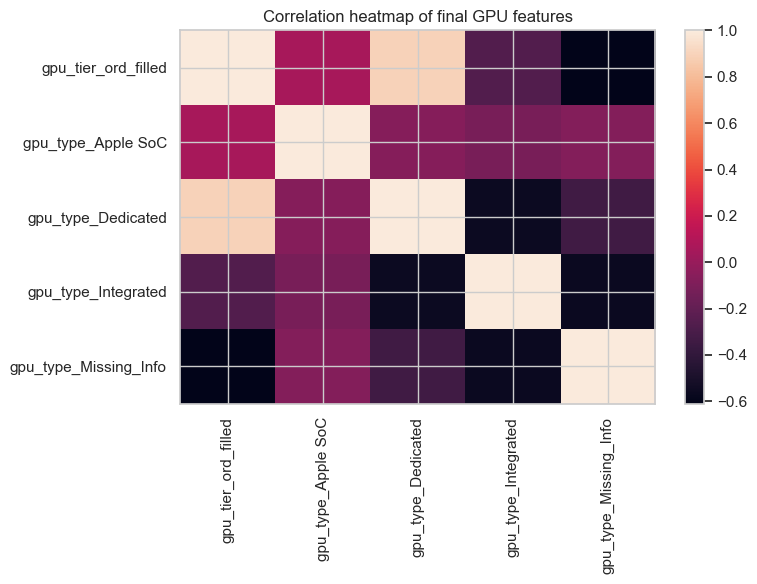

,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
gpu_tier_ord_filled,1.000,0.061,0.895,-0.259,-0.611
gpu_type_Apple SoC,0.061,1.000,-0.069,-0.116,-0.070
gpu_type_Dedicated,0.895,-0.069,1.000,-0.558,-0.336
gpu_type_Integrated,-0.259,-0.116,-0.558,1.000,-0.562
gpu_type_Missing_Info,-0.611,-0.070,-0.336,-0.562,1.000


In [363]:
gpu_feature_cols = [
    "gpu_tier_ord_filled",
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

gpu_encoded_cols = [
    col for col in gpu_feature_cols
    if col in df.columns
]

corr = df[gpu_encoded_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap of final GPU features")
plt.tight_layout()
plt.show()

display(corr.round(3))

Heatmap tương quan cho thấy mối quan hệ giữa các GPU features sau khi encode.

`gpu_tier_ord_filled` có tương quan dương với `gpu_type_Dedicated`, điều này hợp lý vì GPU rời thường đại diện cho mức hiệu năng cao hơn. Ngược lại, `gpu_tier_ord_filled` có tương quan âm với `gpu_type_Missing_Info`, vì các dòng thiếu thông tin GPU được mã hóa bằng một giá trị riêng.

Các biến one-hot của GPU type, bao gồm `gpu_type_Dedicated`, `gpu_type_Integrated`, và `gpu_type_Missing_Info`, có tương quan âm với nhau. Đây là điều bình thường vì các nhóm GPU type là các nhóm loại trừ lẫn nhau: mỗi laptop chỉ thuộc một nhóm GPU type.

Nhìn chung, các GPU features sau khi encode là hợp lý và dễ diễn giải. Bộ feature này thể hiện được cả mức hiệu năng GPU và loại GPU mà không làm mô hình trở nên phức tạp không cần thiết.

In [364]:
df = df.drop(columns=['cpu_tier', 'storage_type_clean', 'condition_clean', 'warranty_status'])

# 6. Final validation and save

In [365]:
# Duplicate checks
print("\nDuplicate checks")

duplicate_rows = int(df.duplicated().sum())
duplicate_cols = df.columns[df.columns.duplicated()].tolist()

print(f"Duplicate rows    : {duplicate_rows:,}")
print(f"Duplicate columns : {duplicate_cols if duplicate_cols else 'None'}")

# Missing values
print("\nMissing values in df")

missing_summary = (
    df.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary.to_frame("missing_count"))

# ------------------------------------------------------------
# 9. Constant columns
# ------------------------------------------------------------
print("\n[9] Constant columns")

constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

if constant_cols:
    print(f"Constant columns ({len(constant_cols)}):")
    print(constant_cols)
else:
    print("No constant columns found.")


Duplicate checks
Duplicate rows    : 270
Duplicate columns : None

Missing values in df
No missing values found.

[9] Constant columns
No constant columns found.


In [366]:
# Remove duplicate rows
duplicate_count = df.duplicated().sum()

print(f"\nDuplicate rows before drop: {duplicate_count:,}")

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicate rows after drop : {df.duplicated().sum():,}")
print(f"Final df_to_save shape    : {df.shape}")


Duplicate rows before drop: 270
Duplicate rows after drop : 0
Final df_to_save shape    : (7296, 91)


In [367]:
print("Count of columns:", len(df.columns.tolist()))
print("Columns:", df.columns.tolist())

Count of columns: 91
Columns: ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'target_price', 'log_target_price', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu', 'ram_level', 'storage_level', 'screen_size_level', 'storage_ssd', 'storage_hdd', 'no_info_storage', 'condition_score', 'warranty_encoded', 'cpu_tier_encoded', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba', 'model_Aspire', 'model_Elitebook', 'model_Elitebook 800', 'model_Gaming Thin GF', 'model_IdeaPad', 'model_Inspiron', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_Legion', 'model_Legion 5', 'model_MacBook Air', 'model_MacBook Air M1', 'model_MacBook Air M2', 'model_MacBook Pro', 'model_MacBook Pro M1', 'model_MacBook Pro M2', '

In [368]:
FEATURE_CONFIG_LEVEL_PKL_PATH = ARTIFACTS_DIR / "feature_config_level.pkl"
FEATURE_CONFIG_NOLEVEL_PKL_PATH = ARTIFACTS_DIR / "feature_config_numeric.pkl"
FEATURE_ENGINEERING_CONFIG_PKL_PATH = ARTIFACTS_DIR / "feature_engineering_config.pkl"

# ==================================================
# Ensure final CPU / GPU feature column variables exist
# Run this BEFORE saving pkl configs
# ==================================================

# --------------------------------------------------
# CPU brand features
# --------------------------------------------------

expected_cpu_brand_cols = [
    "cpu_brand_AMD",
    "cpu_brand_Apple",
    "cpu_brand_Intel",
    "cpu_brand_Other",
    "cpu_brand_Qualcomm",
]

for col in expected_cpu_brand_cols:
    if col not in df.columns:
        df[col] = 0

cpu_brand_feature_cols = [
    col for col in expected_cpu_brand_cols
    if col in df.columns
]


# --------------------------------------------------
# CPU family features
# --------------------------------------------------

expected_cpu_family_group_cols = [
    "cpu_family_group_AMD Ryzen",
    "cpu_family_group_Apple Silicon",
    "cpu_family_group_Intel Core Ultra",
    "cpu_family_group_Intel Core i",
    "cpu_family_group_Intel Low End",
]

for col in expected_cpu_family_group_cols:
    if col not in df.columns:
        df[col] = 0

cpu_family_feature_cols = [
    "cpu_family_ord_filled",
] + expected_cpu_family_group_cols

cpu_family_feature_cols = [
    col for col in cpu_family_feature_cols
    if col in df.columns
]


# --------------------------------------------------
# CPU model-code features
# --------------------------------------------------

cpu_model_code_feature_cols = [
    "cpu_intel_generation_ord",
    "cpu_amd_generation_ord",
    "cpu_apple_core_spec",
    "cpu_qualcomm_snapdragon_spec",
    "cpu_suffix_power_ord_filled",
]

for col in cpu_model_code_feature_cols:
    if col not in df.columns:
        df[col] = 0

cpu_model_code_feature_cols = [
    col for col in cpu_model_code_feature_cols
    if col in df.columns
]


# --------------------------------------------------
# Final CPU features
# --------------------------------------------------

cpu_feature_cols = (
    cpu_family_feature_cols
    + cpu_model_code_feature_cols
    + cpu_brand_feature_cols
)

cpu_feature_cols = list(dict.fromkeys(cpu_feature_cols))


# --------------------------------------------------
# GPU features
# --------------------------------------------------

expected_gpu_type_cols = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

for col in expected_gpu_type_cols:
    if col not in df.columns:
        df[col] = 0

gpu_feature_cols = [
    "gpu_tier_ord_filled",
] + expected_gpu_type_cols

gpu_feature_cols = [
    col for col in gpu_feature_cols
    if col in df.columns
]

gpu_feature_cols = list(dict.fromkeys(gpu_feature_cols))

print("Final GPU feature cols:", gpu_feature_cols)

# ==================================================
# 0. SCALE TARGET
# Chuyển target_price từ VND sang triệu VND
# Sau đó tính lại log_target_price theo đơn vị triệu
# ==================================================

df = df.copy()

# Guard để tránh scale nhiều lần nếu cell bị chạy lại
if df["target_price"].max() > 1000:
    df["target_price"] = df["target_price"] / 1_000_000

df["log_target_price"] = np.log1p(df["target_price"])

TARGET_COLS = [
    "target_price",
    "log_target_price",
]


# ==================================================
# 1. FINAL FEATURE GROUPS
# ==================================================

# CPU features
cpu_feature_cols = (
    cpu_family_feature_cols
    + cpu_model_code_feature_cols
    + cpu_brand_feature_cols
)

# GPU features đã tạo từ cell GPU FE
# gpu_feature_cols expected:
# [
#   "gpu_tier_ord_filled",
#   "gpu_type_Apple SoC",
#   "gpu_type_Dedicated",
#   "gpu_type_Integrated",
#   "gpu_type_Missing_Info",
# ]

# Chỉ giữ các feature thật sự tồn tại trong df
cpu_feature_cols_existing = [
    col for col in cpu_feature_cols
    if col in df.columns
]

gpu_feature_cols_existing = [
    col for col in gpu_feature_cols
    if col in df.columns
]


# ==================================================
# 2. LEVEL DATASET
# Dùng level_cols, bỏ numeric_cols
# ==================================================

df_level = df.copy()

drop_numeric_cols = [
    col for col in numeric_cols
    if col in df_level.columns
]

df_level = df_level.drop(columns=drop_numeric_cols, errors="ignore")

df_level.to_csv(PROCESSED_LEVEL_PATH, index=False)

target_cols_level = [
    col for col in TARGET_COLS
    if col in df_level.columns
]

feature_cols_level = [
    col for col in df_level.columns
    if col not in target_cols_level
]

categorical_cols_level = [
    col for col in level_cols
    if col in df_level.columns
]

feature_config_level = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "processed_path": str(PROCESSED_LEVEL_PATH),
    "feature_config_path": str(FEATURE_CONFIG_LEVEL_PKL_PATH),

    "dataset_shape": df_level.shape,

    "target_cols": target_cols_level,
    "feature_cols": feature_cols_level,
    "feature_count": len(feature_cols_level),

    "used_level_cols": categorical_cols_level,
    "dropped_numeric_cols": drop_numeric_cols,
    "categorical_cols": categorical_cols_level,

    # Tracking engineered features
    "cpu_feature_cols": [
        col for col in cpu_feature_cols_existing
        if col in df_level.columns
    ],
    "gpu_feature_cols": [
        col for col in gpu_feature_cols_existing
        if col in df_level.columns
    ],

    "target_unit": "million_vnd",
    "target_scale_factor": 1_000_000,
    "version": "level",
}


# ==================================================
# 3. NUMERIC / NOLEVEL DATASET
# Dùng numeric_cols, bỏ level_cols
# ==================================================

df_nolevel = df.copy()

drop_level_cols = [
    col for col in level_cols
    if col in df_nolevel.columns
]

df_nolevel = df_nolevel.drop(columns=drop_level_cols, errors="ignore")

df_nolevel.to_csv(PROCESSED_NOLEVEL_PATH, index=False)

target_cols_nolevel = [
    col for col in TARGET_COLS
    if col in df_nolevel.columns
]

feature_cols_nolevel = [
    col for col in df_nolevel.columns
    if col not in target_cols_nolevel
]

categorical_cols_nolevel = [
    col for col in feature_cols_nolevel
    if (
        df_nolevel[col].dtype == "object"
        or str(df_nolevel[col].dtype) == "category"
        or str(df_nolevel[col].dtype) == "string"
    )
]

feature_config_nolevel = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "processed_path": str(PROCESSED_NOLEVEL_PATH),
    "feature_config_path": str(FEATURE_CONFIG_NOLEVEL_PKL_PATH),

    "dataset_shape": df_nolevel.shape,

    "target_cols": target_cols_nolevel,
    "feature_cols": feature_cols_nolevel,
    "feature_count": len(feature_cols_nolevel),

    "used_numeric_cols": [
        col for col in numeric_cols
        if col in df_nolevel.columns
    ],
    "dropped_level_cols": drop_level_cols,
    "categorical_cols": categorical_cols_nolevel,

    # Tracking engineered features
    "cpu_feature_cols": [
        col for col in cpu_feature_cols_existing
        if col in df_nolevel.columns
    ],
    "gpu_feature_cols": [
        col for col in gpu_feature_cols_existing
        if col in df_nolevel.columns
    ],

    "target_unit": "million_vnd",
    "target_scale_factor": 1_000_000,
    "version": "nolevel",
}


# ==================================================
# 4. FULL FEATURE ENGINEERING CONFIG
# Lưu rule encode để tái sử dụng
# ==================================================

feature_engineering_config = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    # --------------------------------------------------
    # Target
    # --------------------------------------------------
    "target_cols": TARGET_COLS,
    "target_unit": "million_vnd",
    "target_scale_factor": 1_000_000,
    "log_transform": "log1p(target_price_in_million_vnd)",

    # --------------------------------------------------
    # Base feature groups
    # --------------------------------------------------
    "numeric_cols": numeric_cols,
    "level_cols": level_cols,

    # --------------------------------------------------
    # Final engineered feature groups
    # --------------------------------------------------
    "cpu_feature_cols": cpu_feature_cols_existing,
    "cpu_family_feature_cols": [
        col for col in cpu_family_feature_cols
        if col in df.columns
    ],
    "cpu_model_code_feature_cols": [
        col for col in cpu_model_code_feature_cols
        if col in df.columns
    ],
    "cpu_brand_feature_cols": [
        col for col in cpu_brand_feature_cols
        if col in df.columns
    ],

    "gpu_feature_cols": gpu_feature_cols_existing,

    # --------------------------------------------------
    # One-hot source columns
    # --------------------------------------------------
    "onehot_cols": [
        "brand_grouped",
        "model_grouped",
        "cpu_brand",
    ],

    # --------------------------------------------------
    # Encoding maps
    # --------------------------------------------------
    "encoding_maps": {
        # Existing maps
        "cpu_tier_map": cpu_tier_map,
        "condition_map": condition_map,
        "warranty_map": warranty_map,

        # GPU maps
        "GPU_TYPE_MAP": GPU_TYPE_MAP,
        "GPU_TIER_CLEAN_MAP": GPU_TIER_CLEAN_MAP,
        "GPU_TIER_ORD_MAP": GPU_TIER_ORD_MAP,

        # CPU family maps
        "CPU_FAMILY_GROUP_MAP": CPU_FAMILY_GROUP_MAP,
        "CPU_FAMILY_LEVEL_MAP": CPU_FAMILY_LEVEL_MAP,

        # CPU model-code maps
        "CPU_SUFFIX_POWER_MAP": CPU_SUFFIX_POWER_MAP,
    },

    # --------------------------------------------------
    # GPU config
    # --------------------------------------------------
    "gpu": {
        "source_cols": [
            "gpu_tier",
            "gpu_tier_v2",
        ],
        "intermediate_cols": [
            "gpu_tier_final",
            "gpu_tier_final_clean",
            "gpu_raw",
            "gpu_type",
            "gpu_tier_clean",
        ],
        "expected_gpu_type_cols": expected_gpu_type_cols,
        "gpu_feature_cols": gpu_feature_cols_existing,
    },

    # --------------------------------------------------
    # CPU config
    # --------------------------------------------------
    "cpu": {
        "cpu_feature_cols": cpu_feature_cols_existing,

        "family": {
            "source_col": "cpu_family_from_raw",
            "intermediate_cols": [
                "cpu_family_raw_clean",
                "cpu_family_group",
            ],
            "feature_cols": [
                col for col in cpu_family_feature_cols
                if col in df.columns
            ],
            "expected_group_cols": expected_cpu_family_group_cols,
            "group_map": CPU_FAMILY_GROUP_MAP,
            "level_map": CPU_FAMILY_LEVEL_MAP,
            "drop_unknown_group_feature": True,
        },

        "model_code": {
            "source_col": "cpu_model_code_group",
            "intermediate_cols": [
                "cpu_model_code_clean",
            ],
            "feature_cols": [
                col for col in cpu_model_code_feature_cols
                if col in df.columns
            ],
            "suffix_power_map": CPU_SUFFIX_POWER_MAP,
            "use_unknown_feature": False,
        },

        "brand": {
            "source_col": "cpu_brand",
            "intermediate_cols": [
                "cpu_brand_clean",
            ],
            "feature_cols": [
                col for col in cpu_brand_feature_cols
                if col in df.columns
            ],
            "expected_brand_cols": expected_cpu_brand_cols,
        },
    },

    # --------------------------------------------------
    # Rare category config
    # --------------------------------------------------
    "rare_category": {
        "brand_threshold": brand_threshold,
        "model_threshold": model_threshold,
    },

    # --------------------------------------------------
    # Dataset configs
    # --------------------------------------------------
    "level_config": feature_config_level,
    "nolevel_config": feature_config_nolevel,
}


# ==================================================
# 5. SAVE PKL FILES
# ==================================================

with open(FEATURE_CONFIG_LEVEL_PKL_PATH, "wb") as f:
    pickle.dump(feature_config_level, f)

with open(FEATURE_CONFIG_NOLEVEL_PKL_PATH, "wb") as f:
    pickle.dump(feature_config_nolevel, f)

with open(FEATURE_ENGINEERING_CONFIG_PKL_PATH, "wb") as f:
    pickle.dump(feature_engineering_config, f)


# ==================================================
# 6. SUMMARY
# ==================================================

print("Target scaled to million VND")
print("target_price min/max:", df["target_price"].min(), df["target_price"].max())
print("log_target_price min/max:", df["log_target_price"].min(), df["log_target_price"].max())

print("-" * 60)

print("Saved LEVEL dataset:", PROCESSED_LEVEL_PATH)
print("Saved LEVEL feature config:", FEATURE_CONFIG_LEVEL_PKL_PATH)
print("LEVEL df shape:", df_level.shape)
print("LEVEL feature count:", len(feature_cols_level))
print("LEVEL CPU features:", feature_config_level["cpu_feature_cols"])
print("LEVEL GPU features:", feature_config_level["gpu_feature_cols"])

print("-" * 60)

print("Saved NOLEVEL dataset:", PROCESSED_NOLEVEL_PATH)
print("Saved NOLEVEL feature config:", FEATURE_CONFIG_NOLEVEL_PKL_PATH)
print("NOLEVEL df shape:", df_nolevel.shape)
print("NOLEVEL feature count:", len(feature_cols_nolevel))
print("NOLEVEL CPU features:", feature_config_nolevel["cpu_feature_cols"])
print("NOLEVEL GPU features:", feature_config_nolevel["gpu_feature_cols"])

print("-" * 60)

print("Saved full feature engineering config:", FEATURE_ENGINEERING_CONFIG_PKL_PATH)
print("Full CPU feature cols:", feature_engineering_config["cpu_feature_cols"])
print("Full GPU feature cols:", feature_engineering_config["gpu_feature_cols"])

Final GPU feature cols: ['gpu_tier_ord_filled', 'gpu_type_Apple SoC', 'gpu_type_Dedicated', 'gpu_type_Integrated', 'gpu_type_Missing_Info']
Target scaled to million VND
target_price min/max: 1.0 179.4
log_target_price min/max: 0.6931471805599453 5.1951766076285235
------------------------------------------------------------
Saved LEVEL dataset: y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_level.csv
Saved LEVEL feature config: y:\Python\Laptop-Price-Prediction\artifacts\preprocessors\feature_config_level.pkl
LEVEL df shape: (7296, 88)
LEVEL feature count: 86
LEVEL CPU features: ['cpu_family_ord_filled', 'cpu_family_group_AMD Ryzen', 'cpu_family_group_Apple Silicon', 'cpu_family_group_Intel Core Ultra', 'cpu_family_group_Intel Core i', 'cpu_family_group_Intel Low End', 'cpu_intel_generation_ord', 'cpu_amd_generation_ord', 'cpu_apple_core_spec', 'cpu_qualcomm_snapdragon_spec', 'cpu_suffix_power_ord_filled', 'cpu_brand_AMD', 'cpu_brand_Apple', 'cpu_brand_Intel', 'cpu_b